# Progetto finale per il corso di "Data Mining" da 12 CFU

## Module 2: Advanced Classification

* Solve a multi-class classification task (i.e., predict rating) using the classification methods
  covered in the course:
  * Logistic Regression,
  * Support Vector Machines,
  * Neural Networks,
  * Ensemble Methods,
  * Gradient Boosting Machines.
* The target variable must have more than 5 classes at this stage. You are encouraged to explore additional target variable (after rating) that might provide meaningful insights, guided by previous
  analyses or new hypotheses.
* Always perform hyper-parameter tuning phases and justify your choices. Explain which parameters you tested, why you selected them, and which ones  performed best.
* Evaluate each classifier with the techniques presented in DM1, including accuracy,
precision, recall, F1-score, and ROC curve (or lift, precision-recall curves).
* Besides the numerical evaluation draw your conclusions about the various classifiers (e.g. for Neural Networks: what are the parameter sets or the convergence criteria which avoid overfitting? For Ensemble classifiers how the number of base models impact the classification performance? What is revealing the feature importance of Random Forests? Is there a specific class that performs bad in each classifier but one and why?)

## Module 2: Explainability
* Try to use one or more explanation methods (e.g., TREPAN, LIME, LORE,
  SHAP, Counterfactual Explainers, etc.) to illustrate the reasons for the
  classification in one of the steps of the previous tasks.
  * Chosen Method: SHAP (state of the art in this field)

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici



In [1]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid", context="notebook", palette="icefire",
    font="sans-serif", font_scale=1.1
)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})
print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I MODELLI ---
print("--- Creazione directory per i modelli ---")
models_dir = 'models_classification/'
os.makedirs(models_dir, exist_ok=True)
print(f"✅ Directory per i modelli '{models_dir}' pronta.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_advanced_classification_xai/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = 'dataset/'
dataset_name = 'imdb_prepared_no_outliers.csv'
try:
    data = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {data.shape[0]} righe, {data.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)


✅ Impostazioni grafiche caricate.
--- Creazione directory per i modelli ---
✅ Directory per i modelli 'models_classification/' pronta.
✅ Directory per i grafici 'plots_advanced_classification_xai/' pronta.
✅ Dataset preparato caricato: 148432 righe, 109 colonne.


In [2]:
data.head(10)

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,...,1.836167,0.168822,-0.919474,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,...,0.777289,-1.530391,-1.099138,-1.33565,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,...,-0.737922,-0.766296,-1.328129,-1.33565,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,...,1.855327,0.821188,-1.099138,-1.33565,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,...,1.904733,0.654420,0.296101,-1.33565,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761
5,Autour d'une cabine,"(6, 7]",1894,\N,2.0,0,1220,15,0,1,...,1.737421,-1.530391,-0.667484,-1.33565,0.244167,-0.400731,-0.299870,-0.922424,1.472037,-0.465842
6,Place des Cordeliers à Lyon,"(5, 6]",1895,\N,1.0,0,1235,5,0,3,...,1.620488,-0.212679,-0.980182,-1.33565,0.244167,-0.400731,-0.299870,-1.365093,1.441311,-0.465842
7,La voltige,"(5, 6]",1895,\N,1.0,0,1104,5,0,3,...,1.671845,-0.212679,-1.040058,-1.33565,0.244167,-0.400731,-0.299870,-1.365093,1.446189,-0.465842
8,L'arroseur,"(5, 6]",1896,\N,1.0,0,84,1,0,2,...,-0.737922,-0.766296,-1.040058,-1.33565,0.244167,-0.400731,-0.299870,-1.675292,-0.863379,-0.465842
9,The Ball Game,"(4, 5]",1898,\N,1.0,0,220,1,0,5,...,-0.737922,-0.212679,-1.756233,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.108969,-0.465842


In [3]:
data.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148432 entries, 0 to 148431
Data columns (total 109 columns):
 #    Column                            Non-Null Count   Dtype  
---   ------                            --------------   -----  
 0    originalTitle                     148432 non-null  object 
 1    rating                            148432 non-null  object 
 2    startYear                         148432 non-null  int64  
 3    endYear                           148432 non-null  object 
 4    runtimeMinutes                    148432 non-null  float64
 5    awardWins                         148432 non-null  int64  
 6    numVotes                          148432 non-null  int64  
 7    totalImages                       148432 non-null  int64  
 8    totalVideos                       148432 non-null  int64  
 9    totalCredits                      148432 non-null  int64  
 10   criticReviewsTotal                148432 non-null  int64  
 11   awardNominationsExcludeWins       148

In [4]:
data

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.000000,0,2089,2,0,4,...,1.836167,0.168822,-0.919474,-1.335650,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.000000,0,183,2,0,2,...,0.777289,-1.530391,-1.099138,-1.335650,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.000000,0,195,1,0,1,...,-0.737922,-0.766296,-1.328129,-1.335650,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.000000,1,2237,3,0,4,...,1.855327,0.821188,-1.099138,-1.335650,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.000000,0,13115,12,0,11,...,1.904733,0.654420,0.296101,-1.335650,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148427,Nuestra película,"(6, 7]",1993,\N,96.000000,0,11,0,0,11,...,-0.737922,-0.212679,-0.030817,-0.264799,0.244167,-0.400731,-0.299870,-1.191479,-0.863379,-0.465842
148428,Eco,"(6, 7]",2019,\N,14.000000,0,15,4,1,52,...,-0.737922,0.168822,-0.467468,-0.264799,0.244167,-0.400731,-0.299870,0.452338,0.571659,-0.465842
148429,Women Take Center Stage,"(5, 6]",2019,\N,38.223865,0,12,2,3,32,...,-0.737922,-1.530391,-0.980182,-1.335650,-1.722096,-0.400731,-0.299870,-0.052110,-0.863379,-0.465842
148430,Horrid Henry and the Christening Crisis,"(7, 8]",2011,\N,10.000000,0,9,1,0,15,...,-0.737922,-1.530391,0.047898,0.838550,0.244167,-0.400731,-0.299870,-0.922424,-0.863379,-0.465842


####  Definizione di Feature (X) e Target (y)

In [5]:
# %%
# OBIETTIVO:
# Impostare il problema di classificazione per utilizzare le 10 categorie originali
# della variabile 'rating' come nostro target, partendo da un contesto pulito.
#
# LOGICA:
# 1. Target (y): Si seleziona direttamente la colonna 'rating', che contiene
#    le 10 etichette testuali originali (es. '(7, 8]').
# 2. Feature (X): Si rimuovono dal dataset tutte le colonne non necessarie:
#    identificatori, versioni non processate delle feature, e le variabili
#    che causerebbero data leakage ('averageRating', 'averageRating_proc').
#    La colonna 'rating' stessa viene ovviamente rimossa dalle feature.

import pandas as pd
import numpy as np

print("--- [STRATEGIA DEFINITIVA] Definizione Feature (X) e Target (y) per 10 Classi ---")

# --- 1. Definizione del Target (y) ---
TARGET_COLUMN = 'rating'
y = data[TARGET_COLUMN]

# --- 2. Definizione delle Feature (X) ---
# Lista delle colonne da escludere dalla matrice delle feature.
columns_to_drop = [
    'originalTitle',
    'rating', # È il nostro target, quindi va rimosso da X
    'endYear',
    'startYear',
    'runtimeMinutes',
    'awardWins',
    'numVotes',
    'totalImages',
    'totalVideos',
    'totalCredits',
    'criticReviewsTotal',
    'awardNominationsExcludeWins',
    'numRegions',
    'userReviewsTotal',
    'companiesNumber',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'winRate',
    'contentRichness',
    'logPopularityScore',
    'criticUserRatio',
    'averageRating',      # Leakage
    'averageRating_proc'  # Leakage
]

# Creiamo la matrice X
X = data.drop(columns=columns_to_drop)

# --- 3. VERIFICA FINALE ---
print(f"\n✅ Vettore target 'y' a 10 classi creato. Shape: {y.shape}")
print(f"   Numero di classi uniche nel target: {y.nunique()}")
print(f"✅ Matrice delle feature 'X' creata. Shape: {X.shape}")
print(f"   Numero di feature utilizzate: {X.shape[1]}")

print("\nDistribuzione del target a 10 classi:")
# Ordiniamo gli intervalli per una visualizzazione corretta
try:
    sorted_categories = sorted(y.unique(), key=lambda val: float(val.strip('()[]').split(',')[0]))
    display(y.value_counts().reindex(sorted_categories))
except Exception as e:
    print(f"Could not sort categories, displaying as is. Error: {e}")
    display(y.value_counts())

--- [STRATEGIA DEFINITIVA] Definizione Feature (X) e Target (y) per 10 Classi ---

✅ Vettore target 'y' a 10 classi creato. Shape: (148432,)
   Numero di classi uniche nel target: 10
✅ Matrice delle feature 'X' creata. Shape: (148432, 85)
   Numero di feature utilizzate: 85

Distribuzione del target a 10 classi:


rating
(0, 1]        88
(1, 2]       472
(2, 3]      1178
(3, 4]      3429
(4, 5]      9061
(5, 6]     21213
(6, 7]     38726
(7, 8]     48134
(8, 9]     21862
(9, 10]     4269
Name: count, dtype: int64

In [6]:
X.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148432 entries, 0 to 148431
Data columns (total 85 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   type_movie                        148432 non-null  int64  
 1   type_short                        148432 non-null  int64  
 2   type_tvEpisode                    148432 non-null  int64  
 3   type_tvMiniSeries                 148432 non-null  int64  
 4   type_tvMovie                      148432 non-null  int64  
 5   type_tvSeries                     148432 non-null  int64  
 6   type_tvShort                      148432 non-null  int64  
 7   type_tvSpecial                    148432 non-null  int64  
 8   type_video                        148432 non-null  int64  
 9   type_videoGame                    148432 non-null  int64  
 10  genres_drama                      148432 non-null  int64  
 11  genres_comedy                     148432 non-null  i

#### Suddivisione dei Dati (Train-Test Split)

In [7]:
# %%
# OBIETTIVO:
# Suddividere il dataset in set di training e di test, utilizzando la
# stratificazione per mantenere la distribuzione originale delle 10 classi
# di rating in entrambi i set.

from sklearn.model_selection import train_test_split
import pandas as pd

print("--- Suddivisione dei dati in Training Set e Test Set (10 Classi) ---")

# Suddividiamo i dati: 80% per il training, 20% per il test
# random_state=42 garantisce che la suddivisione sia sempre la stessa.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # FONDAMENTALE per preservare la proporzione delle classi
)

# --- VERIFICA DELLA STRATIFICAZIONE ---
print("\nVerifica della stratificazione (distribuzione in percentuale):")

# Ordiniamo le categorie per una visualizzazione corretta
try:
    sorted_categories = sorted(y.unique(), key=lambda val: float(val.strip('()[]').split(',')[0]))
    train_dist = y_train.value_counts(normalize=True).reindex(sorted_categories)
    test_dist = y_test.value_counts(normalize=True).reindex(sorted_categories)
except Exception as e:
    print(f"Could not sort categories for verification, using default order. Error: {e}")
    train_dist = y_train.value_counts(normalize=True).sort_index()
    test_dist = y_test.value_counts(normalize=True).sort_index()


verification_df = pd.DataFrame({
    'Training Set (%)': train_dist * 100,
    'Test Set (%)': test_dist * 100
})
verification_df['Differenza Assoluta'] = (verification_df['Training Set (%)'] - verification_df['Test Set (%)']).abs()

print("La differenza tra le distribuzioni dovrebbe essere trascurabile.")
display(verification_df.round(3))

print(f"\n✅ Dati suddivisi con successo:")
print(f"   Shape X_train: {X_train.shape}")
print(f"   Shape y_train: {y_train.shape}")
print(f"   Shape X_test: {X_test.shape}")
print(f"   Shape y_test: {y_test.shape}")

--- Suddivisione dei dati in Training Set e Test Set (10 Classi) ---

Verifica della stratificazione (distribuzione in percentuale):
La differenza tra le distribuzioni dovrebbe essere trascurabile.


,Training Set (%),Test Set (%),Differenza Assoluta
rating,,,
"(0, 1]",0.059,0.061,0.002
"(1, 2]",0.318,0.317,0.002
"(2, 3]",0.793,0.795,0.002
"(3, 4]",2.310,2.311,0.001
"(4, 5]",6.105,6.104,0.001
"(5, 6]",14.291,14.292,0.001
"(6, 7]",26.090,26.089,0.002
"(7, 8]",32.428,32.428,0.000
"(8, 9]",14.729,14.727,0.002



✅ Dati suddivisi con successo:
   Shape X_train: (118745, 85)
   Shape y_train: (118745,)
   Shape X_test: (29687, 85)
   Shape y_test: (29687,)


In [8]:
# %%
# OBIETTIVO:
# Convertire le etichehette target testuali in valori numerici interi (0-9)
# in modo diretto e pulito, come richiesto dai modelli di classificazione.

import numpy as np
import pandas as pd
import tensorflow as tf

print("--- Preparazione e Codifica del Target (Mapping Diretto 0-9) ---")

# --- MAPPING PERSONALIZZATO DA INTERVALLO A INDICE (0-9) ---
# Dizionario che mappa ogni intervallo direttamente al suo indice numerico (0-9)
rating_map = {
    '(0, 1]': 0,
    '(1, 2]': 1,
    '(2, 3]': 2,
    '(3, 4]': 3,
    '(4, 5]': 4,
    '(5, 6]': 5,
    '(6, 7]': 6,
    '(7, 8]': 7,
    '(8, 9]': 8,
    '(9, 10]': 9
}

# Applichiamo la mappatura diretta a y_train e y_test
y_train_encoded = y_train.map(rating_map)
y_test_encoded = y_test.map(rating_map)


# --- VERIFICA E IMPOSTAZIONE COSTANTI ---
INPUT_SHAPE = (X_train.shape[1],)
N_CLASSES = len(rating_map)

print(f"✅ Dati pronti per la modellazione.")
print(f"   Shape dell'input: {INPUT_SHAPE}")
print(f"   Numero di classi: {N_CLASSES}")

print("\n--- Mapping delle Classi (da stringa a intero 0-9) ---")
# Stampiamo la mappatura diretta per chiarezza
for interval, vote_index in rating_map.items():
    print(f"   '{interval}'  --->  {vote_index}")

--- Preparazione e Codifica del Target (Mapping Diretto 0-9) ---
✅ Dati pronti per la modellazione.
   Shape dell'input: (85,)
   Numero di classi: 10

--- Mapping delle Classi (da stringa a intero 0-9) ---
   '(0, 1]'  --->  0
   '(1, 2]'  --->  1
   '(2, 3]'  --->  2
   '(3, 4]'  --->  3
   '(4, 5]'  --->  4
   '(5, 6]'  --->  5
   '(6, 7]'  --->  6
   '(7, 8]'  --->  7
   '(8, 9]'  --->  8
   '(9, 10]'  --->  9


In [9]:
y_train.head(10)

115046    (9, 10]
51282      (7, 8]
8273       (5, 6]
81583     (9, 10]
58389      (7, 8]
65094      (7, 8]
133114     (7, 8]
61732      (7, 8]
103242     (7, 8]
103662     (6, 7]
Name: rating, dtype: object

### REGRESSIONE LOGISTICA

In [9]:
# %%
# OBIETTIVO:
# Eseguire un tuning mirato ed efficiente per la Regressione Logistica,
# concentrandosi su un sottoinsieme di iperparametri ad alto impatto
# per stabilire una baseline robusta in tempi ragionevoli.
#
# LOGICA (basata sulle tue direttive):
# - solver='saga': Scelta unica per la sua efficienza e versatilità.
# - penalty='l2': Ci concentriamo sulla regolarizzazione Ridge, più stabile.
# - C=[0.1, 1, 10]: Un range di regolarizzazione ristretto ma efficace.
# - cv=5: Manteniamo 5-fold cross-validation per stime più robuste.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import time
import pandas as pd

print("--- Inizio Tuning Mirato per Regressione Logistica (10 Classi) ---")

# Definiamo la griglia di parametri come da te specificato
param_grid_lr = {
    'solver': ['saga'],
    'penalty': ['l2'],
    'C': [0.1, 1],
}

# Impostiamo GridSearchCV
# NOTA: y_train contiene le etichette testuali (es. '(6,7]').
# LogisticRegression le gestirà automaticamente.
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2, # Aumentiamo la verbosità per un feedback più dettagliato
    return_train_score=True
)

# Avviamo il training
start_time = time.time()
grid_search_lr.fit(X_train, y_train)
end_time = time.time()

# --- RISULTATI DEL TUNING ---
print(f"\n✅ Tuning completato in {(end_time - start_time)/60:.2f} minuti.")
print(f"\nMiglior punteggio (f1_macro in CV): {grid_search_lr.best_score_:.4f}")
print(f"Migliori iperparametri trovati: {grid_search_lr.best_params_}")

# Salviamo il miglior modello per la successiva valutazione completa
best_lr_model = grid_search_lr.best_estimator_

# Mostriamo i risultati in un formato più completo
print("\nDettaglio dei risultati della Cross-Validation:")
cv_results_df = pd.DataFrame(grid_search_lr.cv_results_)
display(cv_results_df[[
    'param_C', 'param_penalty',
    'mean_test_score', 'std_test_score',
    'mean_train_score', 'std_train_score',
    'rank_test_score'
]].sort_values(by='rank_test_score'))

--- Inizio Tuning Mirato per Regressione Logistica (10 Classi) ---
Fitting 5 folds for each of 2 candidates, totalling 10 fits


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=0.1, penalty=l2, solver=saga; total time= 6.7min


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .......................C=1, penalty=l2, solver=saga; total time= 6.7min


...

[CV] END .....................C=0.1, penalty=l2, solver=saga; total time= 6.8min
[CV] END .......................C=1, penalty=l2, solver=saga; total time= 6.8min


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .......................C=1, penalty=l2, solver=saga; total time= 6.8min

✅ Tuning completato in 11.84 minuti.

Miglior punteggio (f1_macro in CV): 0.1542
Migliori iperparametri trovati: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}

Dettaglio dei risultati della Cross-Validation:


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,param_C,param_penalty,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
0,0.1,l2,0.154166,0.003369,0.158825,0.003967,1
1,1.0,l2,0.153955,0.003805,0.157173,0.003316,2


#### Regressione Logistica: Valutazione Completa e Visualizzazione su Test Set

--- Valutazione Completa: Regressione Logistica (Stile Corretto per Sfondo Nero) ---

--- Report di Classificazione (Logistic Regression) ---
              precision    recall  f1-score   support

      (0, 1]       0.00      0.39      0.01        18
      (1, 2]       0.01      0.21      0.02        94
      (2, 3]       0.03      0.22      0.05       236
      (3, 4]       0.06      0.19      0.09       686
      (4, 5]       0.19      0.19      0.19      1812
      (5, 6]       0.29      0.17      0.21      4243
      (6, 7]       0.38      0.15      0.21      7745
      (7, 8]       0.52      0.33      0.40      9627
      (8, 9]       0.24      0.24      0.24      4372
     (9, 10]       0.09      0.39      0.14       854

    accuracy                           0.23     29687
   macro avg       0.18      0.25      0.16     29687
weighted avg       0.36      0.23      0.27     29687


--- Matrice di Confusione (Formato Testuale) ---
[[   7    5    1    1    0    0    1    0    0   

/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_29299/2904526991.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)



✅ Grafico di valutazione 1x2 salvato in: plots_advanced_classification_xai/02_logistic_regression_full_evaluation.png


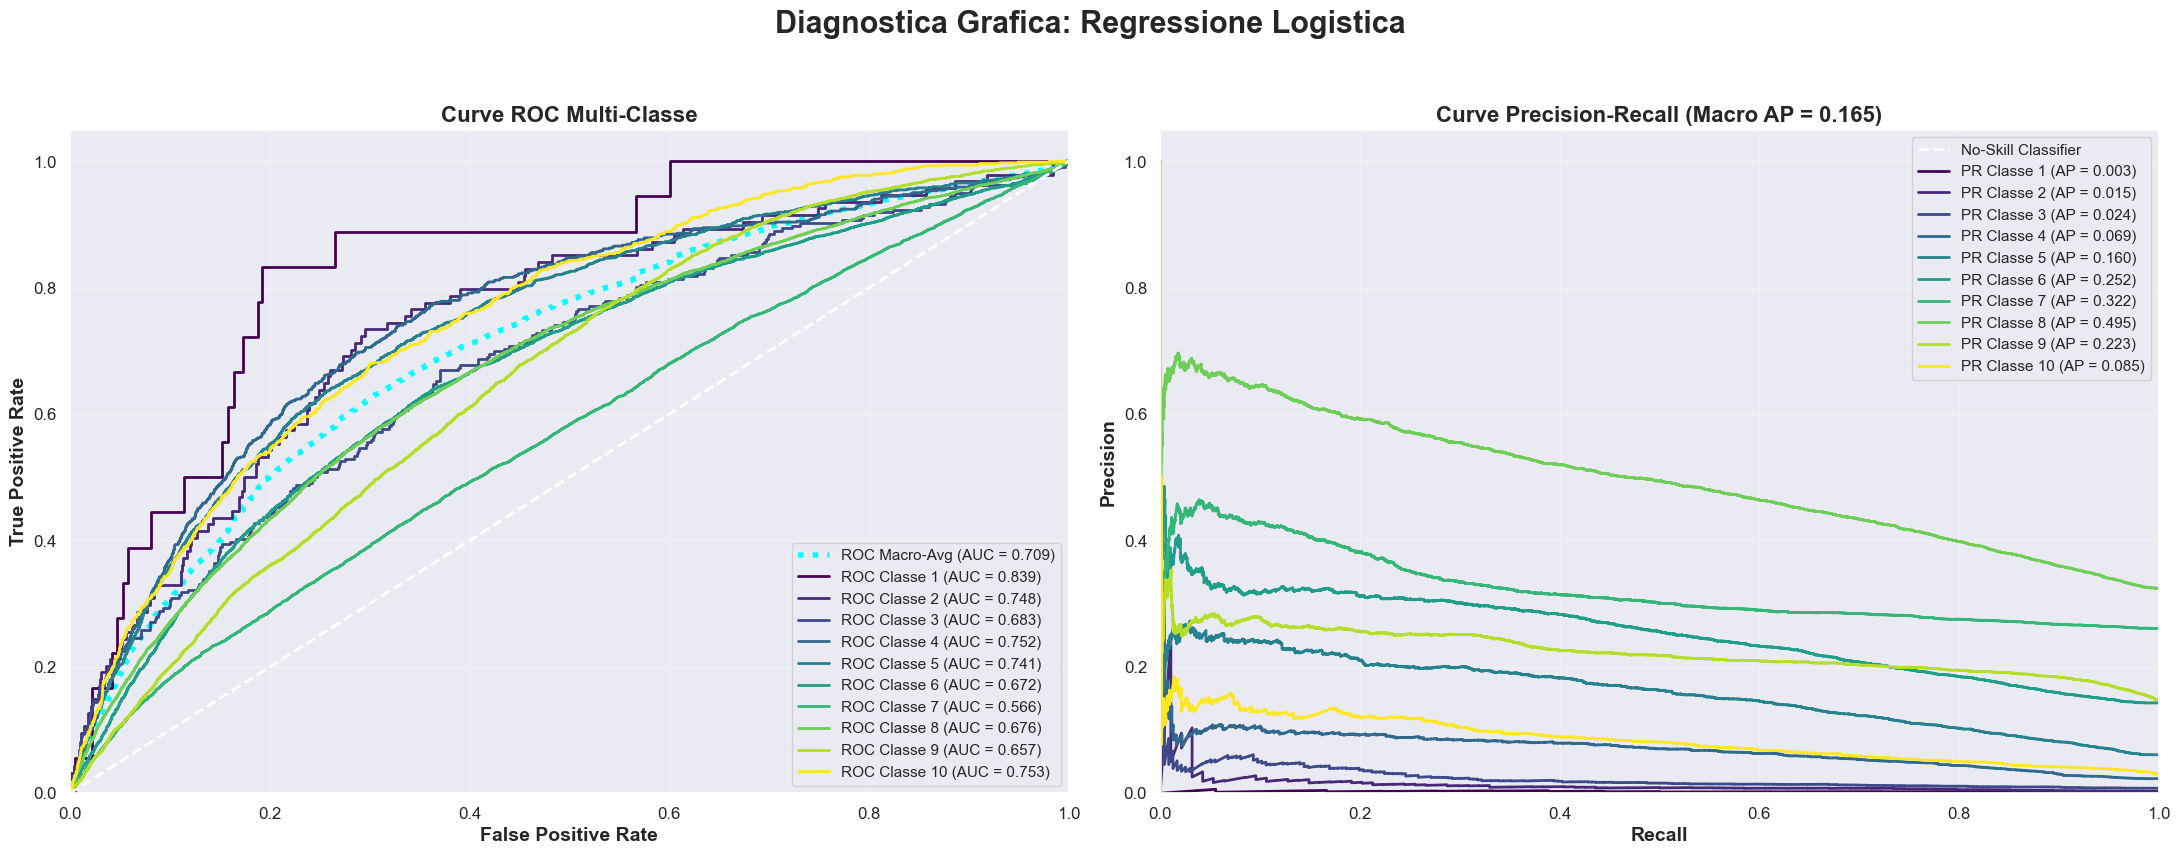

In [10]:
# %%
# OBIETTIVO:
# Eseguire la valutazione completa del modello, con la correzione stilistica
# per rendere i grafici leggibili su sfondo scuro (linee di riferimento bianche).

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Valutazione Completa: Regressione Logistica (Stile Corretto per Sfondo Nero) ---")

# --- 1. PREDIZIONI E REPORT TESTUALE ---
y_pred_lr = best_lr_model.predict(X_test)
y_prob_lr = best_lr_model.predict_proba(X_test)

print("\n--- Report di Classificazione (Logistic Regression) ---")
class_labels = sorted(y_test.unique())
print(classification_report(y_test, y_pred_lr, labels=class_labels))

print("\n--- Matrice di Confusione (Formato Testuale) ---")
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=class_labels)
print(cm_lr)


# --- 2. PREPARAZIONE PER I GRAFICI ---
y_test_bin = LabelBinarizer().fit_transform(y_test)
n_classes = y_test_bin.shape[1]

fpr_lr, tpr_lr, roc_auc_lr = dict(), dict(), dict()
precision_lr, recall_lr, avg_precision_lr = dict(), dict(), dict()

for i in range(n_classes):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])
    precision_lr[i], recall_lr[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_lr[:, i])
    avg_precision_lr[i] = average_precision_score(y_test_bin[:, i], y_prob_lr[:, i])

all_fpr_lr = np.unique(np.concatenate([fpr_lr[i] for i in range(n_classes)]))
mean_tpr_lr = np.zeros_like(all_fpr_lr)
for i in range(n_classes):
    mean_tpr_lr += np.interp(all_fpr_lr, fpr_lr[i], tpr_lr[i])
mean_tpr_lr /= n_classes
fpr_lr["macro"] = all_fpr_lr
tpr_lr["macro"] = mean_tpr_lr
roc_auc_lr["macro"] = auc(fpr_lr["macro"], tpr_lr["macro"])
avg_prec_macro_lr = average_precision_score(y_test_bin, y_prob_lr, average='macro')


# --- 3. CREAZIONE DELLA VISUALIZZAZIONE COMPOSITA 1x2 ---
fig_lr, axes_lr = plt.subplots(1, 2, figsize=(22, 9))
fig_lr.suptitle('Diagnostica Grafica: Regressione Logistica', fontsize=22, weight='bold')

# === Subplot 1: Curve ROC ===
axes_lr[0].plot(fpr_lr["macro"], tpr_lr["macro"],
                 label=f'ROC Macro-Avg (AUC = {roc_auc_lr["macro"]:.3f})',
                 color='cyan', linestyle=':', linewidth=4) # Colore più visibile
colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)
for i, color in zip(range(n_classes), colors):
    axes_lr[0].plot(fpr_lr[i], tpr_lr[i], color=color, lw=2,
                     label=f'ROC Classe {i+1} (AUC = {roc_auc_lr[i]:.3f})')
# --- MODIFICA RICHIESTA ---
axes_lr[0].plot([0, 1], [0, 1], 'w--', lw=2) # Linea di riferimento bianca
axes_lr[0].set_xlim([0.0, 1.0])
axes_lr[0].set_ylim([0.0, 1.05])
axes_lr[0].set_xlabel('False Positive Rate', fontsize=14, weight='bold')
axes_lr[0].set_ylabel('True Positive Rate', fontsize=14, weight='bold')
axes_lr[0].set_title('Curve ROC Multi-Classe', fontsize=16, weight='bold')
axes_lr[0].legend(loc="lower right", fontsize=11)
axes_lr[0].grid(True, alpha=0.3) # Griglia più leggera

# === Subplot 2: Curve Precision-Recall ===
# --- MODIFICA RICHIESTA ---
axes_lr[1].plot([0, 1], [n_classes/y_test_bin.sum(), n_classes/y_test_bin.sum()], 'w--', lw=2, label='No-Skill Classifier') # Linea di riferimento bianca
for i, color in zip(range(n_classes), colors):
    axes_lr[1].plot(recall_lr[i], precision_lr[i], color=color, lw=2,
                     label=f'PR Classe {i+1} (AP = {avg_precision_lr[i]:.3f})')
axes_lr[1].set_xlim([0.0, 1.0])
axes_lr[1].set_ylim([0.0, 1.05])
axes_lr[1].set_xlabel('Recall', fontsize=14, weight='bold')
axes_lr[1].set_ylabel('Precision', fontsize=14, weight='bold')
axes_lr[1].set_title(f'Curve Precision-Recall (Macro AP = {avg_prec_macro_lr:.3f})', fontsize=16, weight='bold')
axes_lr[1].legend(loc="best", fontsize=11)
axes_lr[1].grid(True, alpha=0.3)


# --- 4. SALVATAGGIO ---
plt.tight_layout(rect=(0.00, 0.03, 1.00, 0.95))
plot_path_lr = os.path.join(plots_dir, '02_logistic_regression_full_evaluation.png')
plt.savefig(plot_path_lr, dpi=300)
print(f"\n✅ Grafico di valutazione 1x2 salvato in: {plot_path_lr}")
plt.show()

### Classificazione con Support Vector Machine LinearSVC

In [11]:
# %%
# OBIETTIVO:
# Eseguire un tuning rigoroso degli iperparametri per un classificatore
# LinearSVC e successivamente calibrare il modello migliore per ottenere
# stime di probabilità affidabili.
#
# STRATEGIA A DUE FASI:
# 1. TUNING: Si utilizza GridSearchCV per trovare il valore ottimale del
#    parametro di regolarizzazione 'C' per il LinearSVC.
# 2. CALIBRAZIONE: Il modello LinearSVC con il miglior iperparametro 'C'
#    viene poi inserito in un CalibratedClassifierCV.

from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
import time

print("--- Inizio Tuning e Calibrazione per LinearSVC (10 Classi) ---")

# --- FASE 1: TUNING DEGLI IPERPARAMETRI DI LinearSVC ---
print("\n--- Fase 1: Tuning del parametro 'C' con GridSearchCV ---")

# Definiamo il modello base.
base_lsvc = LinearSVC(
    class_weight='balanced',
    random_state=42,
    dual=False, # Impostazione per l'efficienza
    max_iter=2000
)

# Definiamo una griglia di parametri mirata per la regolarizzazione 'C'
param_grid_lsvc = {
    'C': [0.001, 0.01, 0.1, 1]
}

# Impostiamo GridSearchCV
grid_search_lsvc = GridSearchCV(
    estimator=base_lsvc,
    param_grid=param_grid_lsvc,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1, # Come da tua istruzione
    return_train_score=True
)

# Avviamo il tuning sul training set
start_time_tuning = time.time()
grid_search_lsvc.fit(X_train, y_train)
end_time_tuning = time.time()

# --- RISULTATI DEL TUNING ---
print(f"\n✅ Tuning del LinearSVC completato in {end_time_tuning - start_time_tuning:.2f} secondi.")
print(f"Miglior punteggio (f1_macro in CV): {grid_search_lsvc.best_score_:.4f}")
print(f"Miglior iperparametro trovato: {grid_search_lsvc.best_params_}")

# Estraiamo il miglior modello non calibrato dal tuning
best_uncalibrated_lsvc = grid_search_lsvc.best_estimator_


# --- FASE 2: CALIBRAZIONE DEL MIGLIOR MODELLO TROVATO ---
print("\n--- Fase 2: Calibrazione del modello SVC ottimizzato ---")

# Inseriamo il miglior LinearSVC in CalibratedClassifierCV
best_calibrated_svc = CalibratedClassifierCV(
    estimator=best_uncalibrated_lsvc,
    method='sigmoid',
    cv=5, # 5-fold CV per la fase di calibrazione
    n_jobs=-1
)

# Addestriamo il calibratore sull'intero training set
start_time_calib = time.time()
best_calibrated_svc.fit(X_train, y_train)
end_time_calib = time.time()

print(f"✅ Calibrazione completata in {end_time_calib - start_time_calib:.2f} secondi.")
print("\nIl modello 'best_calibrated_svc' è pronto per la valutazione completa.")

# Assegnamo il modello finale alla variabile standard che useremo per la valutazione
best_svc_model = best_calibrated_svc

--- Inizio Tuning e Calibrazione per LinearSVC (10 Classi) ---

--- Fase 1: Tuning del parametro 'C' con GridSearchCV ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✅ Tuning del LinearSVC completato in 87.30 secondi.
Miglior punteggio (f1_macro in CV): 0.1605
Miglior iperparametro trovato: {'C': 0.001}

--- Fase 2: Calibrazione del modello SVC ottimizzato ---
✅ Calibrazione completata in 14.85 secondi.

Il modello 'best_calibrated_svc' è pronto per la valutazione completa.


#### SVC: Valutazione Completa e Visualizzazione metriche

--- Valutazione Completa: LinearSVC (Standard Definitivo 1x2) ---

--- Report di Classificazione (LinearSVC Calibrato) ---
              precision    recall  f1-score   support

      (0, 1]       0.00      0.00      0.00        18
      (1, 2]       0.00      0.00      0.00        94
      (2, 3]       0.00      0.00      0.00       236
      (3, 4]       0.23      0.01      0.02       686
      (4, 5]       0.37      0.03      0.06      1812
      (5, 6]       0.33      0.20      0.25      4243
      (6, 7]       0.33      0.40      0.36      7745
      (7, 8]       0.42      0.75      0.54      9627
      (8, 9]       0.30      0.05      0.08      4372
     (9, 10]       0.25      0.02      0.04       854

    accuracy                           0.38     29687
   macro avg       0.22      0.15      0.13     29687
weighted avg       0.35      0.38      0.32     29687


--- Matrice di Confusione (Formato Testuale) ---
[[   0    0    0    0    0    0    3   14    1    0]
 [   0    0    

/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_29299/1004537795.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)



✅ Grafico di valutazione 1x2 per SVC salvato in: plots_advanced_classification_xai/03_svm_full_evaluation.png


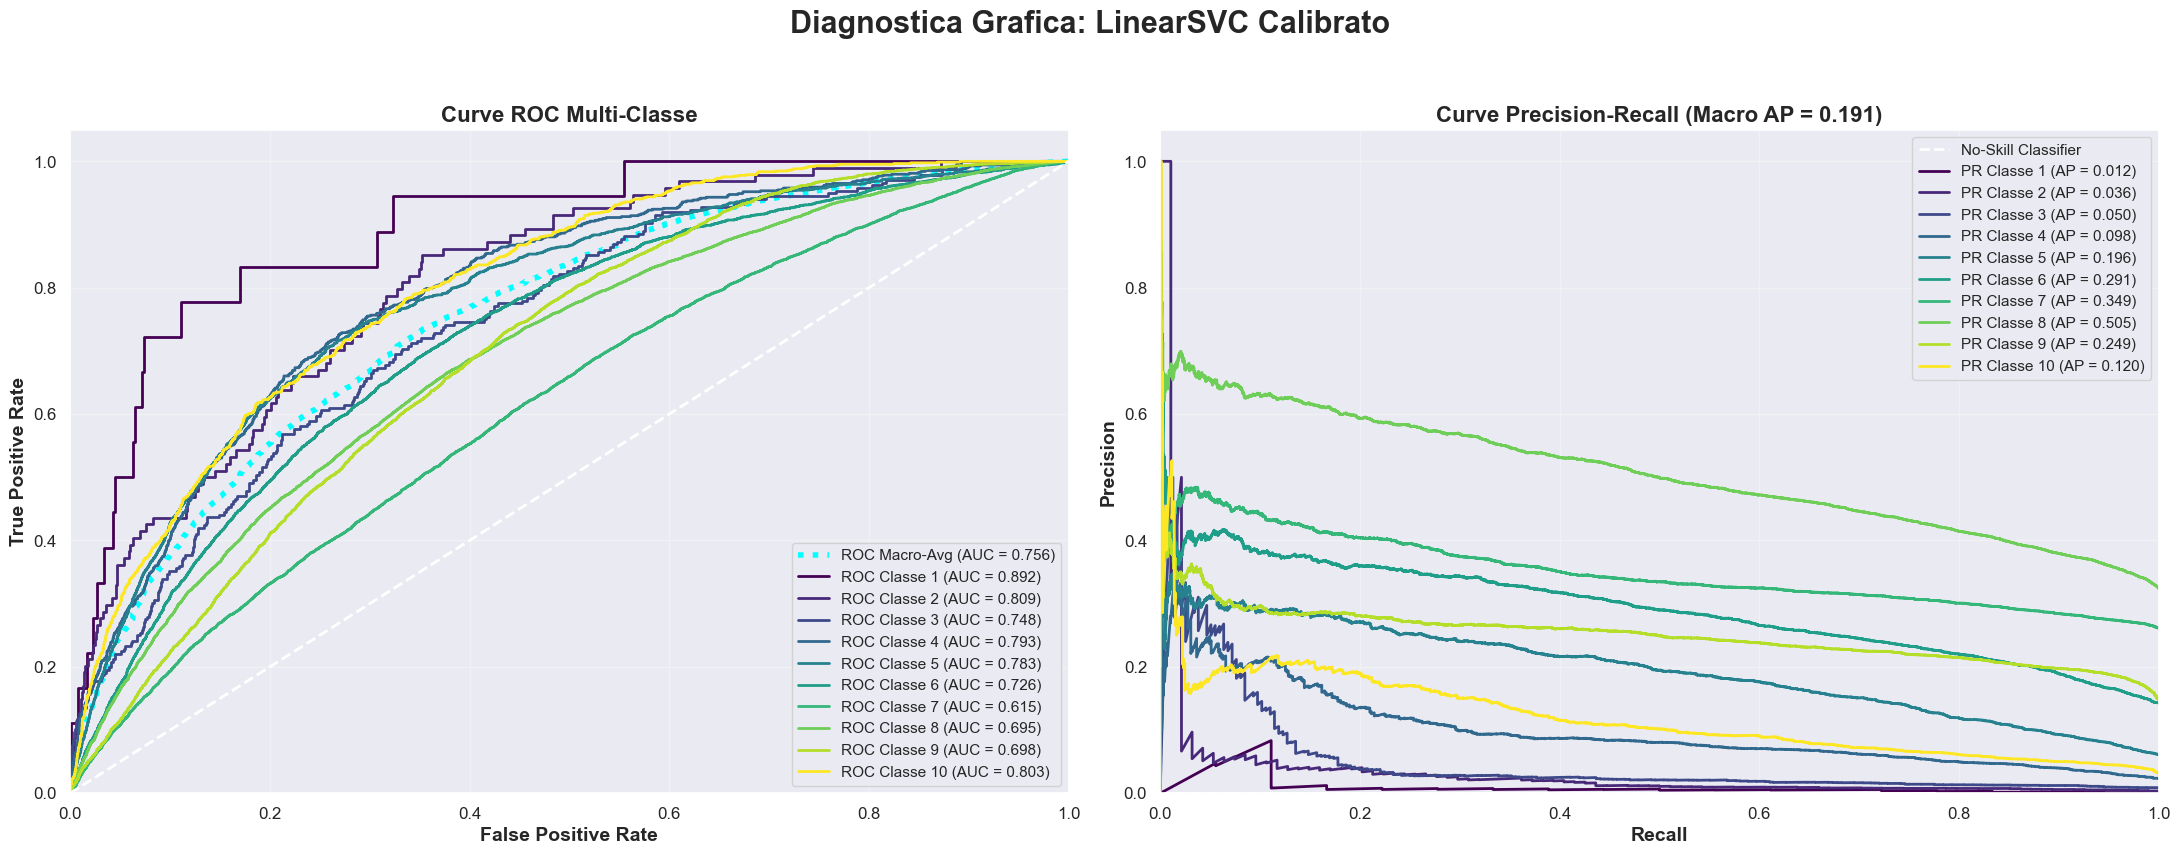

In [12]:
# %%
# OBIETTIVO:
# Eseguire la valutazione completa del modello LinearSVC, aderendo allo standard
# finale: matrice di confusione testuale e un grafico 1x2 (ROC e PR).

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Valutazione Completa: LinearSVC (Standard Definitivo 1x2) ---")

# --- 1. PREDIZIONI E REPORT TESTUALE ---
# Utilizziamo il modello 'best_svc_model' generato dalla cella precedente.
y_pred_svc = best_svc_model.predict(X_test)
y_prob_svc = best_svc_model.predict_proba(X_test)

print("\n--- Report di Classificazione (LinearSVC Calibrato) ---")
class_labels = sorted(y_test.unique())

# Gestione dell'UndefinedMetricWarning per un report pulito
# Aggiungiamo zero_division=0 per silenziare il warning e impostare a 0 le metriche non definite
print(classification_report(y_test, y_pred_svc, labels=class_labels, zero_division=0))

print("\n--- Matrice di Confusione (Formato Testuale) ---")
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=class_labels)
print(cm_svc)


# --- 2. PREPARAZIONE PER I GRAFICI ---
y_test_bin = LabelBinarizer().fit_transform(y_test)
n_classes = y_test_bin.shape[1]

fpr_svc, tpr_svc, roc_auc_svc = dict(), dict(), dict()
precision_svc, recall_svc, avg_precision_svc = dict(), dict(), dict()

for i in range(n_classes):
    fpr_svc[i], tpr_svc[i], _ = roc_curve(y_test_bin[:, i], y_prob_svc[:, i])
    roc_auc_svc[i] = auc(fpr_svc[i], tpr_svc[i])
    precision_svc[i], recall_svc[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_svc[:, i])
    avg_precision_svc[i] = average_precision_score(y_test_bin[:, i], y_prob_svc[:, i])

# Calcolo delle medie "macro"
all_fpr_svc = np.unique(np.concatenate([fpr_svc[i] for i in range(n_classes)]))
mean_tpr_svc = np.zeros_like(all_fpr_svc)
for i in range(n_classes):
    mean_tpr_svc += np.interp(all_fpr_svc, fpr_svc[i], tpr_svc[i])
mean_tpr_svc /= n_classes
fpr_svc["macro"] = all_fpr_svc
tpr_svc["macro"] = mean_tpr_svc
roc_auc_svc["macro"] = auc(fpr_svc["macro"], tpr_svc["macro"])
avg_prec_macro_svc = average_precision_score(y_test_bin, y_prob_svc, average='macro')


# --- 3. CREAZIONE DELLA VISUALIZZAZIONE COMPOSITA 1x2 ---
fig_svc, axes_svc = plt.subplots(1, 2, figsize=(22, 9))
fig_svc.suptitle('Diagnostica Grafica: LinearSVC Calibrato', fontsize=22, weight='bold')

# === Subplot 1 (axes_svc[0]): Curve ROC ===
axes_svc[0].plot(fpr_svc["macro"], tpr_svc["macro"],
                 label=f'ROC Macro-Avg (AUC = {roc_auc_svc["macro"]:.3f})',
                 color='cyan', linestyle=':', linewidth=4)
colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)
for i, color in zip(range(n_classes), colors):
    axes_svc[0].plot(fpr_svc[i], tpr_svc[i], color=color, lw=2,
                     label=f'ROC Classe {i+1} (AUC = {roc_auc_svc[i]:.3f})')
axes_svc[0].plot([0, 1], [0, 1], 'w--', lw=2) # Linea di riferimento bianca
axes_svc[0].set_xlim([0.0, 1.0]); axes_svc[0].set_ylim([0.0, 1.05])
axes_svc[0].set_xlabel('False Positive Rate', fontsize=14, weight='bold')
axes_svc[0].set_ylabel('True Positive Rate', fontsize=14, weight='bold')
axes_svc[0].set_title('Curve ROC Multi-Classe', fontsize=16, weight='bold')
axes_svc[0].legend(loc="lower right", fontsize=11); axes_svc[0].grid(True, alpha=0.3)

# === Subplot 2 (axes_svc[1]): Curve Precision-Recall ===
axes_svc[1].plot([0, 1], [n_classes/y_test_bin.sum(), n_classes/y_test_bin.sum()], 'w--', lw=2, label='No-Skill Classifier') # Linea di riferimento bianca
for i, color in zip(range(n_classes), colors):
    axes_svc[1].plot(recall_svc[i], precision_svc[i], color=color, lw=2,
                     label=f'PR Classe {i+1} (AP = {avg_precision_svc[i]:.3f})')
axes_svc[1].set_xlim([0.0, 1.0]); axes_svc[1].set_ylim([0.0, 1.05])
axes_svc[1].set_xlabel('Recall', fontsize=14, weight='bold')
axes_svc[1].set_ylabel('Precision', fontsize=14, weight='bold')
axes_svc[1].set_title(f'Curve Precision-Recall (Macro AP = {avg_prec_macro_svc:.3f})', fontsize=16, weight='bold')
axes_svc[1].legend(loc="best", fontsize=11); axes_svc[1].grid(True, alpha=0.3)

# --- 4. SALVATAGGIO ---
plt.tight_layout(rect=(0.00, 0.03, 1.00, 0.95))
plot_path_svc = os.path.join(plots_dir, '03_svm_full_evaluation.png')
plt.savefig(plot_path_svc, dpi=300)
print(f"\n✅ Grafico di valutazione 1x2 per SVC salvato in: {plot_path_svc}")
plt.show()

### Classificazione multi-classe con RANDOM FOREST CLASSIFIER

In [10]:
# %%
# OBIETTIVO:
# Eseguire un tuning efficiente per il classificatore Random Forest utilizzando
# RandomizedSearchCV, per esplorare un ampio spazio di iperparametri in un
# tempo di calcolo ragionevole.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import time
import pandas as pd

print("--- Inizio Tuning Iperparametri per Random Forest (10 Classi) ---")

# Definiamo il modello base
# class_weight='balanced_subsample' è la scelta ottimale per Random Forest
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1
)

# Definiamo la distribuzione dei parametri da cui campionare
param_dist_rf = {
    'n_estimators': randint(100, 500),    # Numero di alberi
    'max_depth': [10, 20, 30, 40, None],  # None = Profondità massima
    'min_samples_split': randint(2, 11),  # Min campioni per dividere un nodo
    'min_samples_leaf': randint(1, 11),   # Min campioni in una foglia
    'max_features': ['sqrt', 'log2']      # Numero di feature da considerare per ogni split
}

# Impostiamo RandomizedSearchCV
# n_iter=20 prova 20 combinazioni casuali, un buon compromesso per il tempo
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1, # Come da tua istruzione
    random_state=42,
    return_train_score=True
)

# Avviamo il training sul set di addestramento
start_time_rf = time.time()
random_search_rf.fit(X_train, y_train)
end_time_rf = time.time()

# --- RISULTATI DEL TUNING ---
print(f"\n✅ Tuning del Random Forest completato in {(end_time_rf - start_time_rf) / 60:.2f} minuti.")
print(f"Miglior punteggio (f1_macro in CV): {random_search_rf.best_score_:.4f}")
print("Migliori iperparametri trovati:")
# Stampa completa dei parametri, come richiesto
print(random_search_rf.best_params_)

# Salviamo il miglior modello per la valutazione
best_rf_model = random_search_rf.best_estimator_

# Mostriamo i risultati in un formato più completo
print("\nDettaglio dei risultati della Cross-Validation:")
cv_results_rf_df = pd.DataFrame(random_search_rf.cv_results_)
display(cv_results_rf_df[[
    'params',
    'mean_test_score', 'std_test_score',
    'mean_train_score', 'std_train_score',
    'rank_test_score'
]].sort_values(by='rank_test_score'))


# =======================
# SALVATAGGIO DEL MODELLO
# =======================
model_name = "random_forest_model.joblib"
model_path = models_dir + model_name
joblib.dump(best_rf_model, model_path)
print(f"\n💾 Modello salvato con successo in: {model_path}")



--- Inizio Tuning Iperparametri per Random Forest (10 Classi) ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Tuning del Random Forest completato in 2.72 minuti.
Miglior punteggio (f1_macro in CV): 0.3512
Migliori iperparametri trovati:
{'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 352}

Dettaglio dei risultati della Cross-Validation:


,params,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
4,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.351155,0.018019,0.966360,0.002221,1
18,"{'max_depth': 30, 'max_features': 'sqrt', 'min...",0.347508,0.016199,0.930779,0.002941,2
5,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.347050,0.019731,0.991769,0.001214,3
10,"{'max_depth': 30, 'max_features': 'log2', 'min...",0.345172,0.021257,0.970728,0.001727,4
12,"{'max_depth': 40, 'max_features': 'log2', 'min...",0.335991,0.014982,0.916338,0.004237,5
19,"{'max_depth': 30, 'max_features': 'sqrt', 'min...",0.307001,0.013336,0.726907,0.005315,6
9,"{'max_depth': None, 'max_features': 'log2', 'm...",0.298008,0.014185,0.699303,0.004541,7
7,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.295888,0.011197,0.646072,0.004556,8
0,"{'max_depth': 40, 'max_features': 'sqrt', 'min...",0.285202,0.008742,0.600682,0.002994,9
15,"{'max_depth': None, 'max_features': 'log2', 'm...",0.283537,0.010443,0.634696,0.004927,10



💾 Modello salvato con successo in: models_classification/random_forest_model.joblib


#### RANDOM FOREST CLASSIFIER: Valutazione e Feature Importance

--- Valutazione Completa: Random Forest (Standard Definitivo 1x2) ---

--- Report di Classificazione (Random Forest) ---
              precision    recall  f1-score   support

      (0, 1]       0.50      0.39      0.44        18
      (1, 2]       0.46      0.19      0.27        94
      (2, 3]       0.37      0.14      0.21       236
      (3, 4]       0.31      0.16      0.21       686
      (4, 5]       0.36      0.29      0.32      1812
      (5, 6]       0.37      0.44      0.40      4243
      (6, 7]       0.47      0.45      0.46      7745
      (7, 8]       0.56      0.61      0.58      9627
      (8, 9]       0.45      0.44      0.45      4372
     (9, 10]       0.51      0.37      0.43       854

    accuracy                           0.48     29687
   macro avg       0.44      0.35      0.38     29687
weighted avg       0.47      0.48      0.47     29687


--- Matrice di Confusione (Formato Testuale) ---
[[   7    2    1    0    2    1    2    1    1    1]
 [   3   18    9 

/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_6859/1376928822.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)



✅ Grafico di valutazione 1x2 per Random Forest salvato in: plots_advanced_classification_xai/04_random_forest_full_evaluation.png


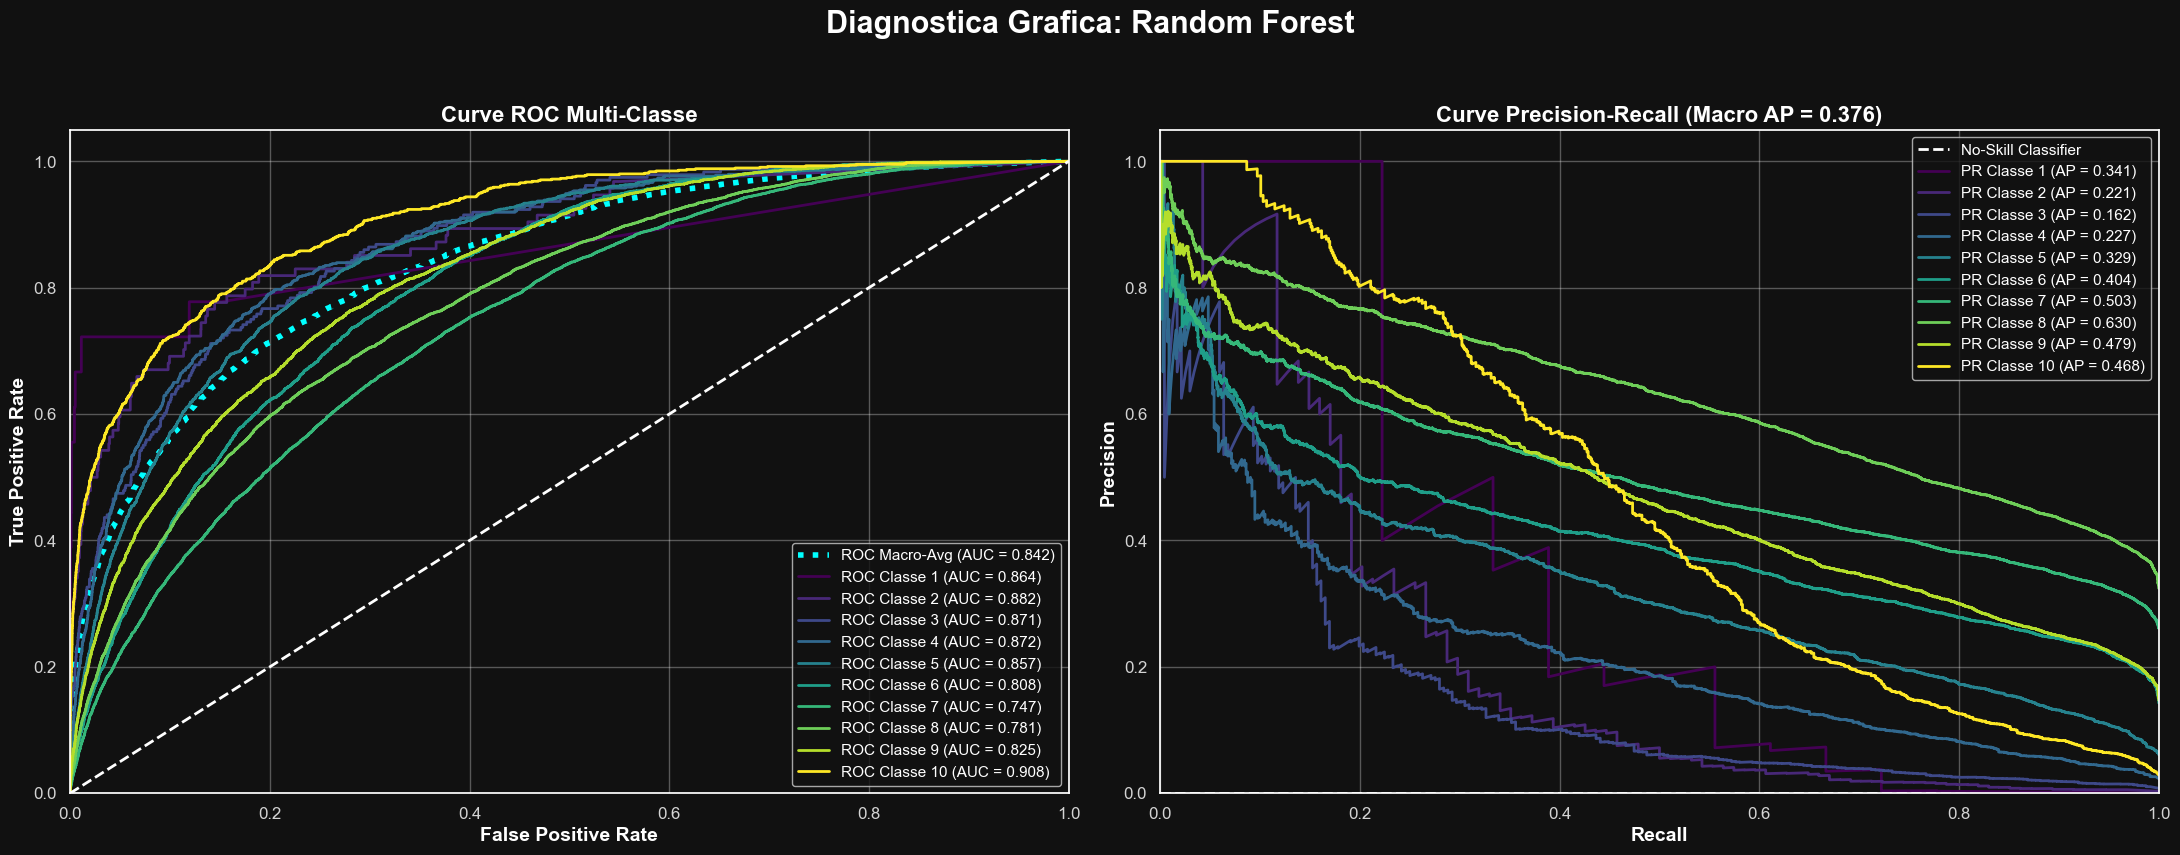


--- Calcolo e Visualizzazione della Feature Importance ---
                feature  importance
    runtimeMinutes_proc    0.112451
         startYear_proc    0.085835
          numVotes_proc    0.081870
   contentRichness_proc    0.071718
      totalCredits_proc    0.070405
   companiesNumber_proc    0.047334
       totalImages_proc    0.040343
     writerCredits_proc    0.032275
logPopularityScore_proc    0.031684
        numRegions_proc    0.024003
  directorsCredits_proc    0.020285
  userReviewsTotal_proc    0.019585
         type_tvEpisode    0.015048
          genres_comedy    0.014735
           genres_drama    0.013545
criticReviewsTotal_proc    0.011929
             type_movie    0.010080
     countryOfOrigin_us    0.009906
   criticUserRatio_proc    0.009847
     genres_documentary    0.009389


/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_6859/1376928822.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


✅ Grafico Feature Importance salvato in: plots_advanced_classification_xai/04_random_forest_feature_importance.png


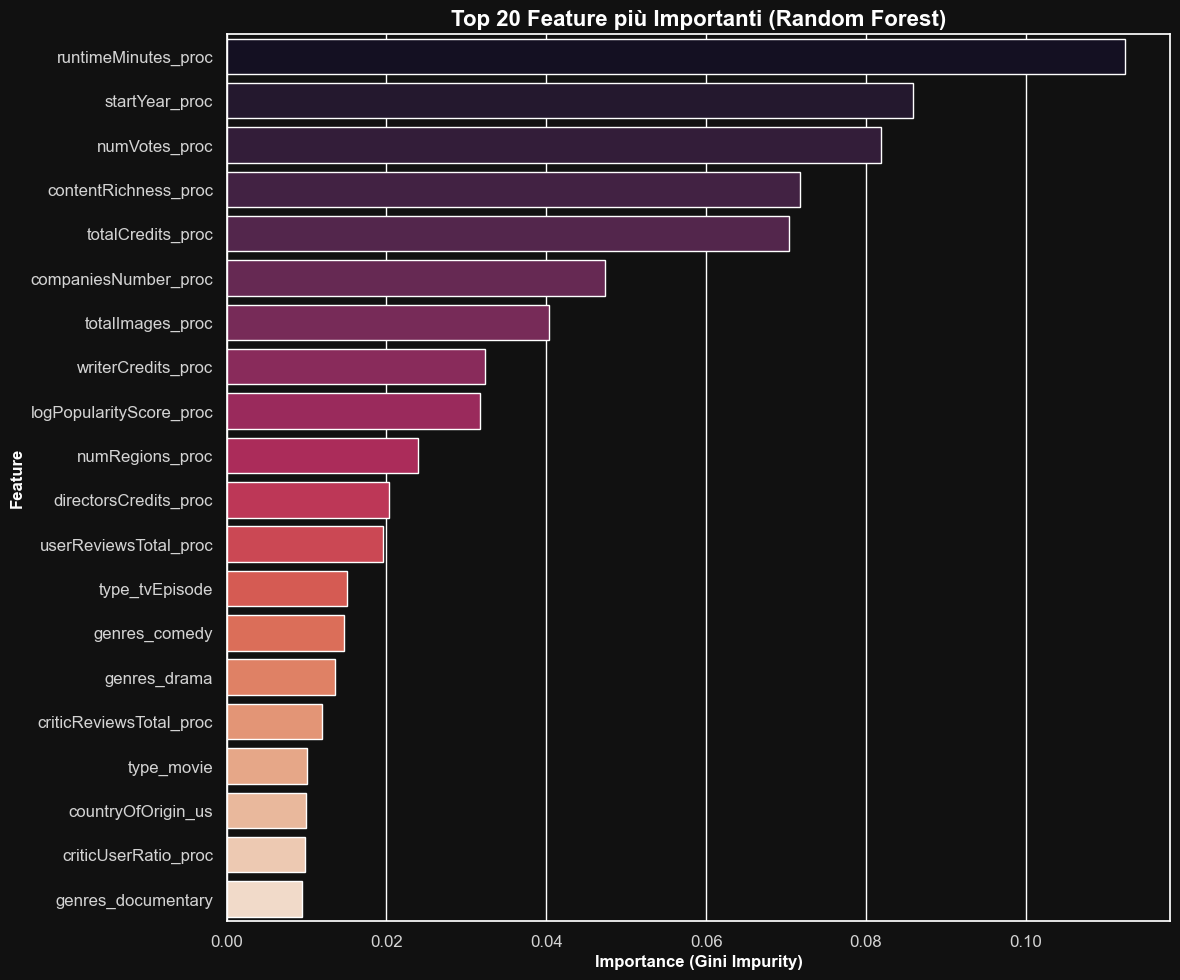

In [11]:
# %%
# OBIETTIVO:
# 1. Valutare il modello Random Forest ottimizzato, aderendo allo standard
#    definitivo (matrice di confusione testuale, grafico 1x2).
# 2. Estrarre e visualizzare l'importanza delle feature, che è un output
#    chiave per i modelli basati su alberi.

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Valutazione Completa: Random Forest (Standard Definitivo 1x2) ---")

# --- 1. PREDIZIONI E REPORT TESTUALE ---
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)

print("\n--- Report di Classificazione (Random Forest) ---")
class_labels = sorted(y_test.unique())
print(classification_report(y_test, y_pred_rf, labels=class_labels, zero_division=0))

print("\n--- Matrice di Confusione (Formato Testuale) ---")
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=class_labels)
print(cm_rf)


# --- 2. PREPARAZIONE PER I GRAFICI ---
y_test_bin = LabelBinarizer().fit_transform(y_test)
n_classes = y_test_bin.shape[1]
fpr_rf, tpr_rf, roc_auc_rf = dict(), dict(), dict()
precision_rf, recall_rf, avg_precision_rf = dict(), dict(), dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    precision_rf[i], recall_rf[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_rf[:, i])
    avg_precision_rf[i] = average_precision_score(y_test_bin[:, i], y_prob_rf[:, i])

all_fpr_rf = np.unique(np.concatenate([fpr_rf[i] for i in range(n_classes)]))
mean_tpr_rf = np.zeros_like(all_fpr_rf)
for i in range(n_classes):
    mean_tpr_rf += np.interp(all_fpr_rf, fpr_rf[i], tpr_rf[i])
mean_tpr_rf /= n_classes
fpr_rf["macro"] = all_fpr_rf
tpr_rf["macro"] = mean_tpr_rf
roc_auc_rf["macro"] = auc(fpr_rf["macro"], tpr_rf["macro"])
avg_prec_macro_rf = average_precision_score(y_test_bin, y_prob_rf, average='macro')


# --- 3. CREAZIONE DELLA VISUALIZZAZIONE COMPOSITA 1x2 ---
fig_rf, axes_rf = plt.subplots(1, 2, figsize=(22, 9))
fig_rf.suptitle('Diagnostica Grafica: Random Forest', fontsize=22, weight='bold')

# === Subplot 1 (axes_rf[0]): Curve ROC ===
axes_rf[0].plot(fpr_rf["macro"], tpr_rf["macro"],
                 label=f'ROC Macro-Avg (AUC = {roc_auc_rf["macro"]:.3f})',
                 color='cyan', linestyle=':', linewidth=4)
colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)
for i, color in zip(range(n_classes), colors):
    axes_rf[0].plot(fpr_rf[i], tpr_rf[i], color=color, lw=2,
                     label=f'ROC Classe {i+1} (AUC = {roc_auc_rf[i]:.3f})')
axes_rf[0].plot([0, 1], [0, 1], 'w--', lw=2) # Linea di riferimento bianca
axes_rf[0].set_xlim([0.0, 1.0]); axes_rf[0].set_ylim([0.0, 1.05])
axes_rf[0].set_xlabel('False Positive Rate', fontsize=14, weight='bold')
axes_rf[0].set_ylabel('True Positive Rate', fontsize=14, weight='bold')
axes_rf[0].set_title('Curve ROC Multi-Classe', fontsize=16, weight='bold')
axes_rf[0].legend(loc="lower right", fontsize=11); axes_rf[0].grid(True, alpha=0.3)

# === Subplot 2 (axes_rf[1]): Curve Precision-Recall ===
axes_rf[1].plot([0, 1], [n_classes/y_test_bin.sum(), n_classes/y_test_bin.sum()], 'w--', lw=2, label='No-Skill Classifier') # Linea di riferimento bianca
for i, color in zip(range(n_classes), colors):
    axes_rf[1].plot(recall_rf[i], precision_rf[i], color=color, lw=2,
                     label=f'PR Classe {i+1} (AP = {avg_precision_rf[i]:.3f})')
axes_rf[1].set_xlim([0.0, 1.0]); axes_rf[1].set_ylim([0.0, 1.05])
axes_rf[1].set_xlabel('Recall', fontsize=14, weight='bold')
axes_rf[1].set_ylabel('Precision', fontsize=14, weight='bold')
axes_rf[1].set_title(f'Curve Precision-Recall (Macro AP = {avg_prec_macro_rf:.3f})', fontsize=16, weight='bold')
axes_rf[1].legend(loc="best", fontsize=11); axes_rf[1].grid(True, alpha=0.3)

# --- 4. SALVATAGGIO GRAFICO CURVE ---
plt.tight_layout(rect=(0.00, 0.03, 1.00, 0.95))
plot_path_rf = os.path.join(plots_dir, '04_random_forest_full_evaluation.png')
plt.savefig(plot_path_rf, dpi=300)
print(f"\n✅ Grafico di valutazione 1x2 per Random Forest salvato in: {plot_path_rf}")
plt.show()


# --- 5. FEATURE IMPORTANCE ---
print("\n--- Calcolo e Visualizzazione della Feature Importance ---")
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Feature più Importanti (Random Forest)', fontsize=16, weight='bold')
plt.xlabel('Importance (Gini Impurity)', fontsize=12, weight='bold')
plt.ylabel('Feature', fontsize=12, weight='bold')
plt.tight_layout()

print(feature_importance_df.head(20).to_string(index=False))

# Salviamo il grafico della feature importance
plot_path_rf_imp = os.path.join(plots_dir, '04_random_forest_feature_importance.png')
plt.savefig(plot_path_rf_imp, dpi=300)
print(f"✅ Grafico Feature Importance salvato in: {plot_path_rf_imp}")
plt.show()

### Classificazione Avanzata con XGBoost

In [12]:
# %%
# OBIETTIVO:
# Eseguire il tuning degli iperparametri per XGBoost, un modello di boosting
# estremamente performante, utilizzando RandomizedSearchCV.
#
# STRATEGIA:
# 1. Spazio di Ricerca: Si definisce una distribuzione di iperparametri chiave
#    che controllano la complessità, la velocità di apprendimento e la
#    regolarizzazione del modello.
# 2. Gestione Sbilanciamento: Si calcolano i pesi per ogni campione del
#    training set in base alla rarità della sua classe. Questi pesi vengono
#    poi passati direttamente al metodo .fit(), che è l'approccio corretto
#    per gestire lo sbilanciamento in XGBoost.

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import uniform, randint
import time
import pandas as pd

print("--- Inizio Tuning Iperparametri per XGBoost (10 Classi) ---")

# 1. Calcolo dei pesi per il training set per gestire lo sbilanciamento
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Definiamo il modello base di XGBoost
# Nota: XGBoost richiede che le etichette siano numeriche. Useremo y_train_encoded.
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob', # Obiettivo multi-classe con output di probabilità
    eval_metric='mlogloss',     # Metrica di valutazione per il training
    random_state=42
)

# Definiamo la distribuzione dei parametri da esplorare
param_dist_xgb = {
    'n_estimators': randint(100, 600),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4), # Somma deve essere 1.0 (0.6 + 0.4)
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5)
}

# Impostiamo RandomizedSearchCV
# n_iter=25 per un'esplorazione più approfondita rispetto al Random Forest
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist_xgb,
    n_iter=25,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1, # Come da tua istruzione
    random_state=42,
    return_train_score=True
)

# Avviamo il training, passando i pesi dei campioni e le etichette codificate
start_time_xgb = time.time()
random_search_xgb.fit(X_train, y_train_encoded, sample_weight=sample_weights)
end_time_xgb = time.time()

# --- RISULTATI DEL TUNING ---
print(f"\n✅ Tuning del XGBoost completato in {(end_time_xgb - start_time_xgb) / 60:.2f} minuti.")
print(f"Miglior punteggio (f1_macro in CV): {random_search_xgb.best_score_:.4f}")
print("Migliori iperparametri trovati:")
# Stampa completa dei parametri, come richiesto
print(random_search_xgb.best_params_)

# Salviamo il miglior modello per la valutazione
best_xgb_model = random_search_xgb.best_estimator_

# Mostriamo i risultati in un formato più completo
print("\nDettaglio dei risultati della Cross-Validation:")
cv_results_xgb_df = pd.DataFrame(random_search_xgb.cv_results_)
display(cv_results_xgb_df[[
    'params',
    'mean_test_score', 'std_test_score',
    'mean_train_score', 'std_train_score',
    'rank_test_score'
]].sort_values(by='rank_test_score'))


# =======================
# SALVATAGGIO DEL MODELLO
# =======================
model_name = "xgboost_model.joblib"
model_path = models_dir + model_name
joblib.dump(best_rf_model, model_path)
print(f"\n💾 Modello salvato con successo in: {model_path}")




--- Inizio Tuning Iperparametri per XGBoost (10 Classi) ---
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



✅ Tuning del XGBoost completato in 4.62 minuti.
Miglior punteggio (f1_macro in CV): 0.3651
Migliori iperparametri trovati:
{'colsample_bytree': 0.9886848381556415, 'gamma': 0.42445691213304193, 'learning_rate': 0.15434590423297465, 'max_depth': 9, 'n_estimators': 354, 'subsample': 0.7024273291045295}

Dettaglio dei risultati della Cross-Validation:


,params,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
18,"{'colsample_bytree': 0.9886848381556415, 'gamm...",0.365138,0.020499,0.876465,0.001375,1
22,"{'colsample_bytree': 0.8779139732158818, 'gamm...",0.362241,0.017344,0.865062,0.002696,2
23,"{'colsample_bytree': 0.782613828193164, 'gamma...",0.359017,0.015814,0.816170,0.000855,3
2,"{'colsample_bytree': 0.608233797718321, 'gamma...",0.355426,0.022619,0.837570,0.002317,4
11,"{'colsample_bytree': 0.7306163075223342, 'gamm...",0.355339,0.015819,0.787162,0.001793,5
1,"{'colsample_bytree': 0.662397808134481, 'gamma...",0.347955,0.018865,0.747397,0.002115,6
4,"{'colsample_bytree': 0.8447411578889518, 'gamm...",0.346698,0.016070,0.756971,0.004667,7
16,"{'colsample_bytree': 0.9400154311159197, 'gamm...",0.326221,0.012903,0.693222,0.005125,8
3,"{'colsample_bytree': 0.6733618039413735, 'gamm...",0.321716,0.017513,0.651053,0.004313,9
20,"{'colsample_bytree': 0.9583054382694077, 'gamm...",0.316696,0.011734,0.608754,0.004321,10



💾 Modello salvato con successo in: models_classification/xgboost_model.joblib


#### XGBoost: Valutazione e Feature Importance

--- Valutazione Completa: XGBoost (Standard Definitivo 1x2) ---

--- Report di Classificazione (XGBoost) ---
              precision    recall  f1-score   support

      (0, 1]       0.44      0.39      0.41        18
      (1, 2]       0.40      0.28      0.33        94
      (2, 3]       0.32      0.23      0.27       236
      (3, 4]       0.23      0.22      0.23       686
      (4, 5]       0.30      0.39      0.34      1812
      (5, 6]       0.38      0.44      0.40      4243
      (6, 7]       0.50      0.41      0.45      7745
      (7, 8]       0.60      0.52      0.56      9627
      (8, 9]       0.41      0.54      0.47      4372
     (9, 10]       0.43      0.52      0.47       854

    accuracy                           0.46     29687
   macro avg       0.40      0.39      0.39     29687
weighted avg       0.48      0.46      0.47     29687


--- Matrice di Confusione (Formato Testuale) ---
[[   7    5    2    0    0    0    1    0    2    1]
 [   3   26    9   13    8   

/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_6859/3591163773.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)



✅ Grafico 1x2 per XGBoost salvato in: plots_advanced_classification_xai/05_xgboost_full_evaluation.png


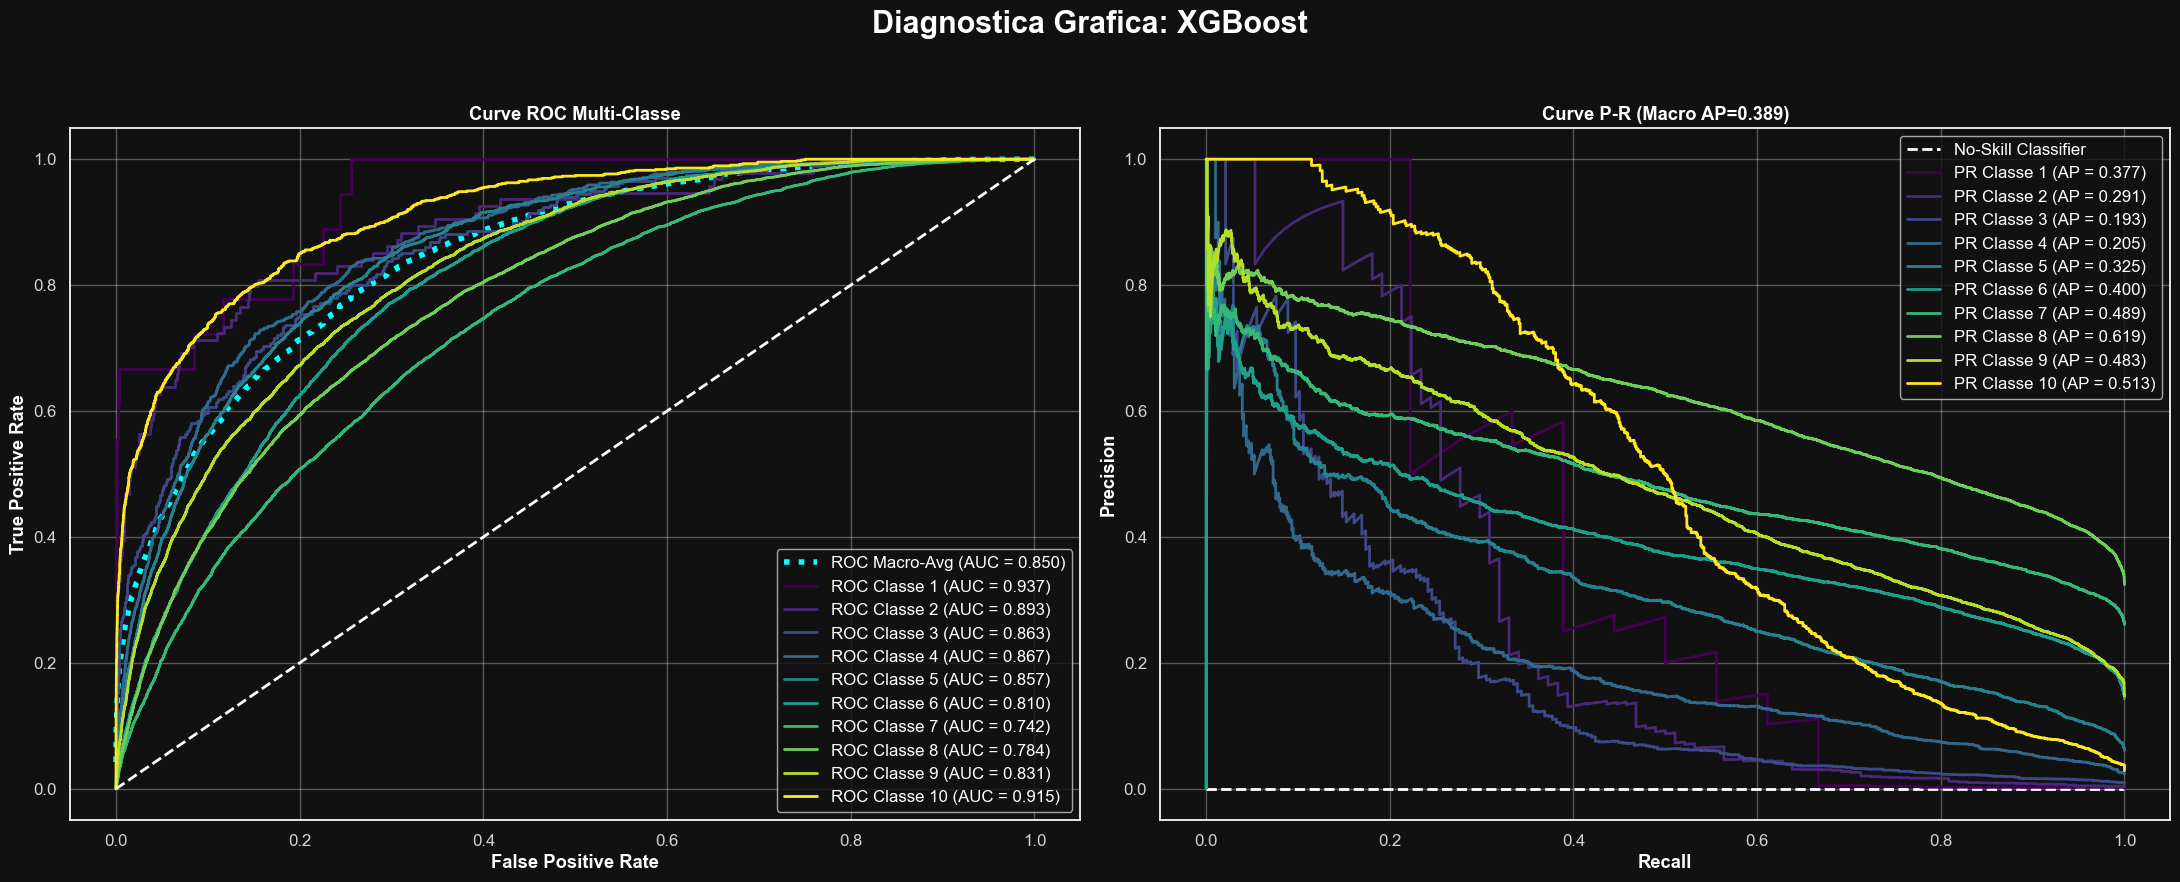


--- Calcolo e Visualizzazione della Feature Importance ---
✅ Grafico Feature Importance salvato in: plots_advanced_classification_xai/05_xgboost_feature_importance.png


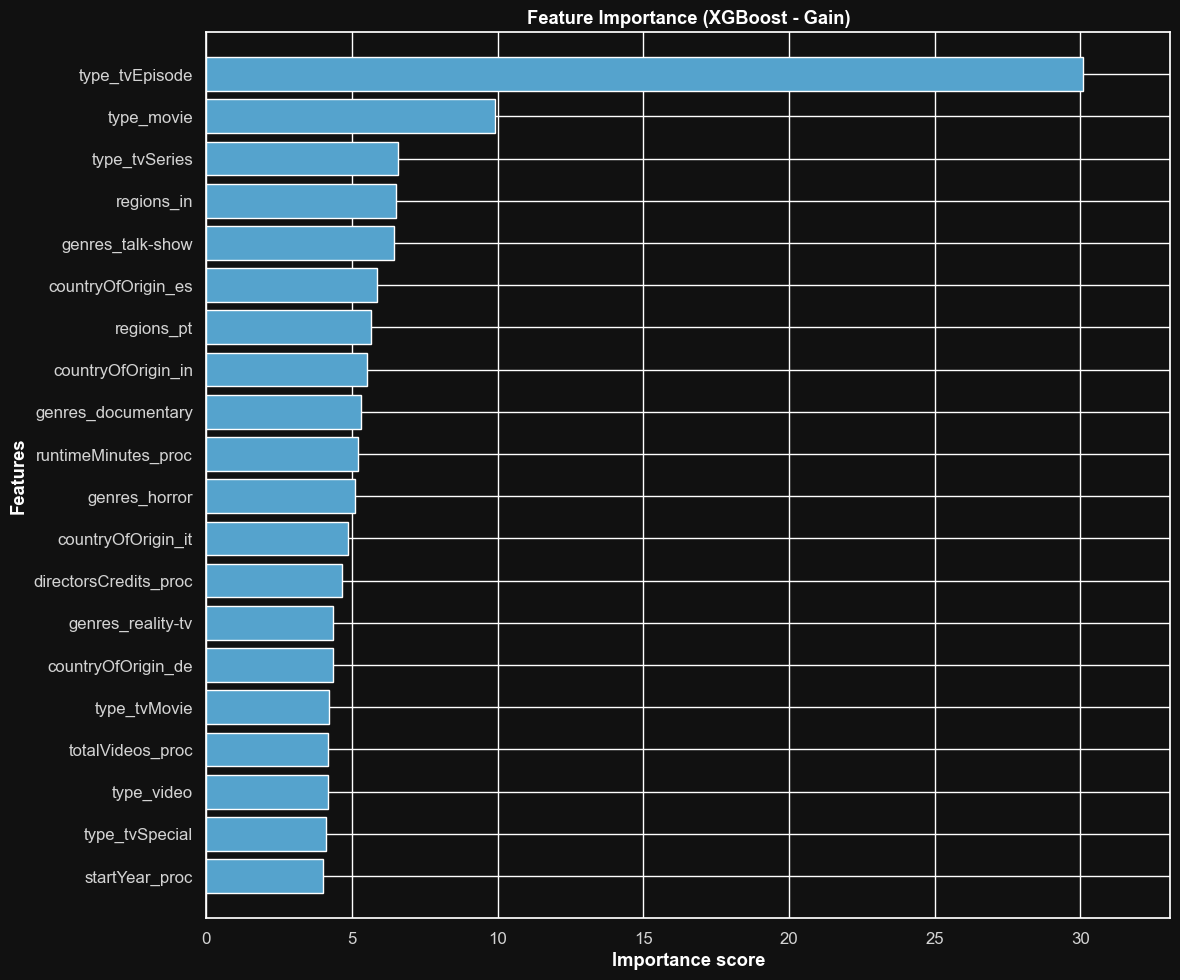

In [13]:
# %%
# OBIETTIVO:
# Valutare il modello XGBoost con una cella autosufficiente per prevenire errori.

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xgboost as xgb

print("--- Valutazione Completa: XGBoost (Standard Definitivo 1x2) ---")

# --- SETUP DI SICUREZZA: Ridefiniamo le variabili necessarie ---
# Questo blocco garantisce che la cella funzioni anche se il kernel viene riavviato.
label_encoder = LabelEncoder()
label_encoder.fit(y_train) # Impara le classi da y_train
y_test_encoded = label_encoder.transform(y_test) # Applica la trasformazione a y_test
# --- FINE SETUP ---


# --- 1. PREDIZIONI E REPORT TESTUALE ---
y_pred_xgb_encoded = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)

print("\n--- Report di Classificazione (XGBoost) ---")
class_labels_text = label_encoder.classes_
print(classification_report(y_test_encoded, y_pred_xgb_encoded, target_names=class_labels_text, zero_division=0))

print("\n--- Matrice di Confusione (Formato Testuale) ---")
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb_encoded)
print(cm_xgb)


# --- 2. PREPARAZIONE PER I GRAFICI ---
y_test_bin_encoded = LabelBinarizer().fit_transform(y_test_encoded)
n_classes = y_test_bin_encoded.shape[1]

fpr_xgb, tpr_xgb, roc_auc_xgb = dict(), dict(), dict()
precision_xgb, recall_xgb, avg_precision_xgb = dict(), dict(), dict()

for i in range(n_classes):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin_encoded[:, i], y_prob_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])
    precision_xgb[i], recall_xgb[i], _ = precision_recall_curve(y_test_bin_encoded[:, i], y_prob_xgb[:, i])
    avg_precision_xgb[i] = average_precision_score(y_test_bin_encoded[:, i], y_prob_xgb[:, i])

all_fpr_xgb = np.unique(np.concatenate([fpr_xgb[i] for i in range(n_classes)])); mean_tpr_xgb = np.zeros_like(all_fpr_xgb)
for i in range(n_classes): mean_tpr_xgb += np.interp(all_fpr_xgb, fpr_xgb[i], tpr_xgb[i])
mean_tpr_xgb /= n_classes; fpr_xgb["macro"] = all_fpr_xgb; tpr_xgb["macro"] = mean_tpr_xgb; roc_auc_xgb["macro"] = auc(fpr_xgb["macro"], tpr_xgb["macro"])
avg_prec_macro_xgb = average_precision_score(y_test_bin_encoded, y_prob_xgb, average='macro')


# --- 3. CREAZIONE DELLA VISUALIZZAZIONE COMPOSITA 1x2 ---
fig_xgb, axes_xgb = plt.subplots(1, 2, figsize=(22, 9))
fig_xgb.suptitle('Diagnostica Grafica: XGBoost', fontsize=22, weight='bold')

# === Subplot 1: Curve ROC ===
axes_xgb[0].plot(fpr_xgb["macro"], tpr_xgb["macro"], label=f'ROC Macro-Avg (AUC = {roc_auc_xgb["macro"]:.3f})', color='cyan', linestyle=':', linewidth=4)
colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)
for i, color in zip(range(n_classes), colors): axes_xgb[0].plot(fpr_xgb[i], tpr_xgb[i], color=color, lw=2, label=f'ROC Classe {i+1} (AUC = {roc_auc_xgb[i]:.3f})')
axes_xgb[0].plot([0, 1], [0, 1], 'w--', lw=2); axes_xgb[0].set_title('Curve ROC Multi-Classe'); axes_xgb[0].legend(loc="lower right"); axes_xgb[0].grid(True, alpha=0.3)
axes_xgb[0].set_xlabel('False Positive Rate'); axes_xgb[0].set_ylabel('True Positive Rate')

# === Subplot 2: Curve Precision-Recall ===
axes_xgb[1].plot([0, 1], [n_classes/y_test_bin_encoded.sum(), n_classes/y_test_bin_encoded.sum()], 'w--', lw=2, label='No-Skill Classifier')
for i, color in zip(range(n_classes), colors): axes_xgb[1].plot(recall_xgb[i], precision_xgb[i], color=color, lw=2, label=f'PR Classe {i+1} (AP = {avg_precision_xgb[i]:.3f})')
axes_xgb[1].set_title(f'Curve P-R (Macro AP={avg_prec_macro_xgb:.3f})'); axes_xgb[1].legend(loc="best"); axes_xgb[1].grid(True, alpha=0.3)
axes_xgb[1].set_xlabel('Recall'); axes_xgb[1].set_ylabel('Precision')


# --- 4. SALVATAGGIO GRAFICO CURVE ---
plt.tight_layout(rect=(0, 0, 1, 0.95))
plot_path_xgb = os.path.join(plots_dir, '05_xgboost_full_evaluation.png')
plt.savefig(plot_path_xgb, dpi=300); print(f"\n✅ Grafico 1x2 per XGBoost salvato in: {plot_path_xgb}"); plt.show()


# --- 5. FEATURE IMPORTANCE ---
print("\n--- Calcolo e Visualizzazione della Feature Importance ---")
fig, ax = plt.subplots(figsize=(12, 10))
xgb.plot_importance(best_xgb_model, ax=ax, max_num_features=20, height=0.8, importance_type='gain', show_values=False, title='Feature Importance (XGBoost - Gain)')
plt.tight_layout()
plot_path_xgb_imp = os.path.join(plots_dir, '05_xgboost_feature_importance.png')
plt.savefig(plot_path_xgb_imp, dpi=300); print(f"✅ Grafico Feature Importance salvato in: {plot_path_xgb_imp}"); plt.show()


### HistGradientBoostingClassifier

In [ ]:
# %%
# OBIETTIVO:
# Eseguire il tuning degli iperparametri per HistGradientBoostingClassifier con RandomizedSearchCV,
# gestendo lo sbilanciamento, ottimizzando per classificazione multi-classe e output probabilistici.

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform
import time

# --- Inizio tuning ---
print("--- Inizio Tuning Iperparametri per HistGradientBoostingClassifier ---")

# Codifica delle classi in interi
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  # serve dopo per valutazione

# Calcolo dei pesi per gestire lo sbilanciamento
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# Modello base
hgbc = HistGradientBoostingClassifier(
    loss='log_loss',          # Per classificazione multi-classe
    early_stopping=True,
    random_state=42
)

# Spazio degli iperparametri per RandomizedSearchCV
param_dist_hgbc = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': randint(100, 400),
    'max_depth': randint(4, 10),
    'min_samples_leaf': randint(10, 50),
    'l2_regularization': uniform(0.0, 1.0)
}

# RandomizedSearchCV setup
random_search_hgbc = RandomizedSearchCV(
    estimator=hgbc,
    param_distributions=param_dist_hgbc,
    n_iter=25,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Training con i pesi
start_time_hgbc = time.time()
random_search_hgbc.fit(X_train, y_train_encoded, sample_weight=sample_weights)
end_time_hgbc = time.time()

# --- Risultati ---
print("\n--- Risultati del Tuning HistGradientBoostingClassifier ---")
print(f"Tuning completato in {(end_time_hgbc - start_time_hgbc) / 60:.2f} minuti.")
print(f"Miglior punteggio (f1_macro in CV): {random_search_hgbc.best_score_:.4f}")
print("Migliori iperparametri trovati:")
print(random_search_hgbc.best_params_)

# Salva il modello migliore
best_hgbc_model = random_search_hgbc.best_estimator_

# Salva anche l'encoder per decodificare le classi in fase di predizione
label_encoder_hgbc = le.classes_


#### Valutazione HistGradientBoostingClassifier

In [ ]:
# %%
# OBIETTIVO:
# Valutare il modello HistGradientBoostingClassifier su un test set,
# generando un report testuale e una visualizzazione completa 1x3:
# Matrice di Confusione, Curve ROC, Curve Precision-Recall.

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Class labels per report e matrici
class_labels = le.classes_

# 1. Predizioni e decodifica
y_pred_encoded = best_hgbc_model.predict(X_test)
y_pred_hist = le.inverse_transform(y_pred_encoded)
y_prob_hist = best_hgbc_model.predict_proba(X_test)

# 2. Report testuale corretto
print("\n--- Report di Classificazione (HistGradientBoostingClassifier) ---")
print(classification_report(y_test, y_pred_hist, labels=class_labels))

print("\n--- Matrice di Confusione (Formato Testuale) ---")
cm_hist = confusion_matrix(y_test, y_pred_hist, labels=class_labels)
print(cm_hist)


# 3. Binarizzazione per visualizzazioni ROC/PR
y_test_bin = LabelBinarizer().fit_transform(y_test)
n_classes = y_test_bin.shape[1]

fpr_hist, tpr_hist, roc_auc_hist = {}, {}, {}
precision_hist, recall_hist, avg_precision_hist = {}, {}, {}

for i in range(n_classes):
    fpr_hist[i], tpr_hist[i], _ = roc_curve(y_test_bin[:, i], y_prob_hist[:, i])
    roc_auc_hist[i] = auc(fpr_hist[i], tpr_hist[i])
    precision_hist[i], recall_hist[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_hist[:, i])
    avg_precision_hist[i] = average_precision_score(y_test_bin[:, i], y_prob_hist[:, i])

# Macro-average ROC
all_fpr_hist = np.unique(np.concatenate([fpr_hist[i] for i in range(n_classes)]))
mean_tpr_hist = np.zeros_like(all_fpr_hist)
for i in range(n_classes):
    mean_tpr_hist += np.interp(all_fpr_hist, fpr_hist[i], tpr_hist[i])
mean_tpr_hist /= n_classes
fpr_hist["macro"] = all_fpr_hist
tpr_hist["macro"] = mean_tpr_hist
roc_auc_hist["macro"] = auc(fpr_hist["macro"], tpr_hist["macro"])
avg_prec_macro_hist = average_precision_score(y_test_bin, y_prob_hist, average='macro')

# 4. Visualizzazione 1x3
fig, axes = plt.subplots(1, 3, figsize=(30, 9))
fig.suptitle('Diagnostica Completa del Modello: HistGradientBoostingClassifier', fontsize=22, weight='bold')

# Matrice Confusione
cm_hist = confusion_matrix(y_test, y_pred_hist, labels=class_labels)
cm_hist_normalized = cm_hist.astype('float') / cm_hist.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_hist_normalized, annot=True, fmt='.2%', cmap='cividis', ax=axes[0],
            xticklabels=class_labels, yticklabels=class_labels, annot_kws={"size": 12})
axes[0].set_title('Matrice di Confusione Normalizzata', fontsize=16, weight='bold')
axes[0].set_xlabel('Classe Predetta', fontsize=14)
axes[0].set_ylabel('Classe Reale', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# ROC
axes[1].plot(fpr_hist["macro"], tpr_hist["macro"], label=f'ROC Macro-Avg (AUC = {roc_auc_hist["macro"]:.3f})',
             color='purple', linestyle=':', linewidth=4)
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
for i, color in zip(range(n_classes), colors):
    axes[1].plot(fpr_hist[i], tpr_hist[i], color=color, lw=2, label=f'ROC classe {class_labels[i]} (AUC = {roc_auc_hist[i]:.3f})')
axes[1].plot([0, 1], [0, 1], 'w--', lw=2)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=14)
axes[1].set_ylabel('True Positive Rate', fontsize=14)
axes[1].set_title('Curve ROC Multi-Classe', fontsize=16, weight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True)

# PR
axes[2].plot([0, 1], [n_classes / y_test_bin.sum(), n_classes / y_test_bin.sum()],
             'k--', lw=2, label='No-Skill Classifier')
for i, color in zip(range(n_classes), colors):
    axes[2].plot(recall_hist[i], precision_hist[i], color=color, lw=2,
                 label=f'PR classe {class_labels[i]} (AP = {avg_precision_hist[i]:.3f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall', fontsize=14)
axes[2].set_ylabel('Precision', fontsize=14)
axes[2].set_title(f'Curve Precision-Recall (Macro AP = {avg_prec_macro_hist:.3f})', fontsize=16, weight='bold')
axes[2].legend(loc="best")
axes[2].grid(True)

plt.tight_layout(rect=(0.00, 0.03, 1.00, 0.95))
plot_path_hist = os.path.join(plots_dir, '05_histgbc_full_evaluation.png')
plt.savefig(plot_path_hist, dpi=300)
print(f"\n✅ Grafico di valutazione completa salvato in '{plot_path_hist}'")
plt.show()


### Rete Neurale (TensorFlow-Keras con GPU support)

#### Codice di test per riconoscere la GPU

In [14]:
# %%
# OBIETTIVO:
# Verificare in modo programmatico se TensorFlow ha accesso e sta utilizzando
# la GPU del MacBook Pro (tramite il plug-in Metal).

import tensorflow as tf

print(f"Versione di TensorFlow: {tf.__version__}")

# Elenchiamo i dispositivi fisici di tipo 'GPU' che TensorFlow rileva
gpu_devices = tf.config.list_physical_devices('GPU')

print(f"Dispositivi GPU rilevati: {gpu_devices}")

if gpu_devices:
    print("\n✅ OTTIMO! TensorFlow ha rilevato la tua GPU.")
    print("L'addestramento della rete neurale verrà accelerato automaticamente.")
else:
    print("\n⚠️ ATTENZIONE: TensorFlow non ha rilevato una GPU.")
    print("L'addestramento verrà eseguito sulla CPU, risultando molto più lento.")
    print("Questo di solito indica un problema nell'installazione dell'ambiente (es. mancano i pacchetti 'tensorflow-macos' e 'tensorflow-metal').")

Versione di TensorFlow: 2.16.2
Dispositivi GPU rilevati: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ OTTIMO! TensorFlow ha rilevato la tua GPU.
L'addestramento della rete neurale verrà accelerato automaticamente.


#### Preparazione dati per Keras

In [15]:
# %%
# OBIETTIVO:
# Preparare i dati per l'utilizzo con Keras. Le reti neurali richiedono
# che le etichette target siano in formato numerico.
#
# LOGICA:
# 1. LabelEncoder: Si utilizza LabelEncoder di Scikit-learn per convertire
#    le etichette testuali del nostro target ('1. Pessimo...', '2. Mediocre...')
#    in valori interi (0, 1, 2, ...).
# 2. Fit/Transform: Si 'fitta' l'encoder solo sul training set (y_train) per
#    imparare la mappatura e si applica la trasformazione sia a y_train che
#    a y_test per coerenza.

from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

print("--- Preparazione dei Dati per Keras ---")

# I dati X_train, X_test, y_train, y_test sono già stati corretti e splittati.

# Creiamo l'encoder
label_encoder = LabelEncoder()

# Fittiamo e trasformiamo y_train
y_train_encoded = label_encoder.fit_transform(y_train)

# Trasformiamo y_test usando lo stesso encoder
y_test_encoded = label_encoder.transform(y_test)

# Definiamo costanti utili per la costruzione della rete
INPUT_SHAPE = (X_train.shape[1],)
N_CLASSES = len(label_encoder.classes_)

print(f"✅ Dati pronti per Keras.")
print(f"Shape dell'input: {INPUT_SHAPE}")
print(f"Numero di classi: {N_CLASSES}")
print("\nMapping delle classi (da testo a intero):")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name}  --->  {i}")

--- Preparazione dei Dati per Keras ---
✅ Dati pronti per Keras.
Shape dell'input: (85,)
Numero di classi: 10

Mapping delle classi (da testo a intero):
  (0, 1]  --->  0
  (1, 2]  --->  1
  (2, 3]  --->  2
  (3, 4]  --->  3
  (4, 5]  --->  4
  (5, 6]  --->  5
  (6, 7]  --->  6
  (7, 8]  --->  7
  (8, 9]  --->  8
  (9, 10]  --->  9


#### CLASSIFICAZIONE: RETE NEURALE

In [16]:
# %%
# OBIETTIVO:
# Costruire e addestrare la versione definitiva della nostra rete neurale
# per la classificazione multi-classe, utilizzando un target one-hot encoded,
# una loss pesata, e una robusta regolarizzazione L2 + Dropout.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer, GaussianNoise, ReLU
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

print("🚀 Inizio addestramento rete neurale Softmax bilanciata definitiva...")

# --- FASE 1: PREPARAZIONE DATI E PESI ---
print("\n[FASE 1] Preparazione Dati One-Hot e Calcolo Pesi...")

# Assicuriamoci che le variabili base esistano
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
INPUT_SHAPE = (X_train.shape[1],)
N_CLASSES = len(label_encoder.classes_)

# One-hot encoding per categorical_crossentropy
y_train_cat = to_categorical(y_train_encoded, num_classes=N_CLASSES)
y_test_cat = to_categorical(y_test_encoded, num_classes=N_CLASSES)

# Calcolo dei pesi di classe
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weights_dict = dict(enumerate(class_weights))
print("✅ Dati e pesi pronti.")

# --- FASE 2: ARCHITETTURA DEFINITIVA ---
model_softmax = Sequential([
    InputLayer(input_shape=INPUT_SHAPE),
    GaussianNoise(0.1),

    Dense(256, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)), # <-- L2 Aggiunto
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),

    Dense(128, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)), # <-- L2 Aggiunto
    BatchNormalization(),
    ReLU(),
    Dropout(0.3),

    Dense(64, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)), # <-- L2 Aggiunto
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),

    Dense(N_CLASSES, activation='softmax')
], name="Definitive_Softmax_Classifier")

model_softmax.compile(
    optimizer=AdamW(learning_rate=0.001),
    loss='categorical_crossentropy', # Corretto per target one-hot
    metrics=['accuracy']
)

model_softmax.summary()

# --- FASE 3: ADDESTRAMENTO ---
print("\n[FASE 3] Inizio Addestramento...")
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_softmax = model_softmax.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)

best_nn_model = model_softmax
print("✅ Addestramento completato con successo.")


# SALVATAGGIO DELLA RETE NEURALE
model_name = "deep_neural_network.keras"
model_path = models_dir + model_name
best_nn_model.save(model_path)
print(f"Modello {model_path}")




🚀 Inizio addestramento rete neurale Softmax bilanciata definitiva...

[FASE 1] Preparazione Dati One-Hot e Calcolo Pesi...
✅ Dati e pesi pronti.


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2025-08-07 22:25:55.263523: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Ultra
2025-08-07 22:25:55.263563: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 96.00 GB
2025-08-07 22:25:55.263575: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 36.00 GB
2025-08-07 22:25:55.263609: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-07 22:25:55.263619: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <unde

Model: "Definitive_Softmax_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 85)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,610 (256.29 KB)

 Trainable params: 64,714 (252.79 KB)

 Non-trainable params: 896 (3.50 KB)


[FASE 3] Inizio Addestramento...
Epoch 1/50


2025-08-07 22:25:56.343327: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1856/1856 - 43s - 23ms/step - accuracy: 0.1567 - loss: 2.3176 - val_accuracy: 0.1958 - val_loss: 2.1898 - learning_rate: 0.0010
Epoch 2/50
1856/1856 - 38s - 20ms/step - accuracy: 0.1791 - loss: 2.1332 - val_accuracy: 0.1891 - val_loss: 2.1117 - learning_rate: 0.0010
Epoch 3/50
1856/1856 - 38s - 20ms/step - accuracy: 0.1969 - loss: 2.1053 - val_accuracy: 0.2031 - val_loss: 2.1174 - learning_rate: 0.0010
Epoch 4/50
1856/1856 - 39s - 21ms/step - accuracy: 0.2062 - loss: 2.0622 - val_accuracy: 0.2253 - val_loss: 2.0857 - learning_rate: 0.0010
Epoch 5/50
1856/1856 - 37s - 20ms/step - accuracy: 0.2092 - loss: 2.0504 - val_accuracy: 0.2043 - val_loss: 2.1156 - learning_rate: 0.0010
Epoch 6/50
1856/1856 - 37s - 20ms/step - accuracy: 0.2093 - loss: 2.0356 - val_accuracy: 0.2346 - val_loss: 2.0281 - learning_rate: 0.0010
Epoch 7/50
1856/1856 - 36s - 20ms/step - accuracy: 0.2134 - loss: 2.0208 - val_accuracy: 0.2238 - val_loss: 2.0469 - learning_rate: 0.0010
Epoch 8/50
1856/1856 - 36s - 19ms/step

#### Valutazione RETE NEURALE

--- Valutazione Completa: Rete Neurale Softmax Definitiva ---
[INFO] Setup di sicurezza: ricaricamento di LabelEncoder e dati encodati...
✅ Variabili di valutazione pronte.


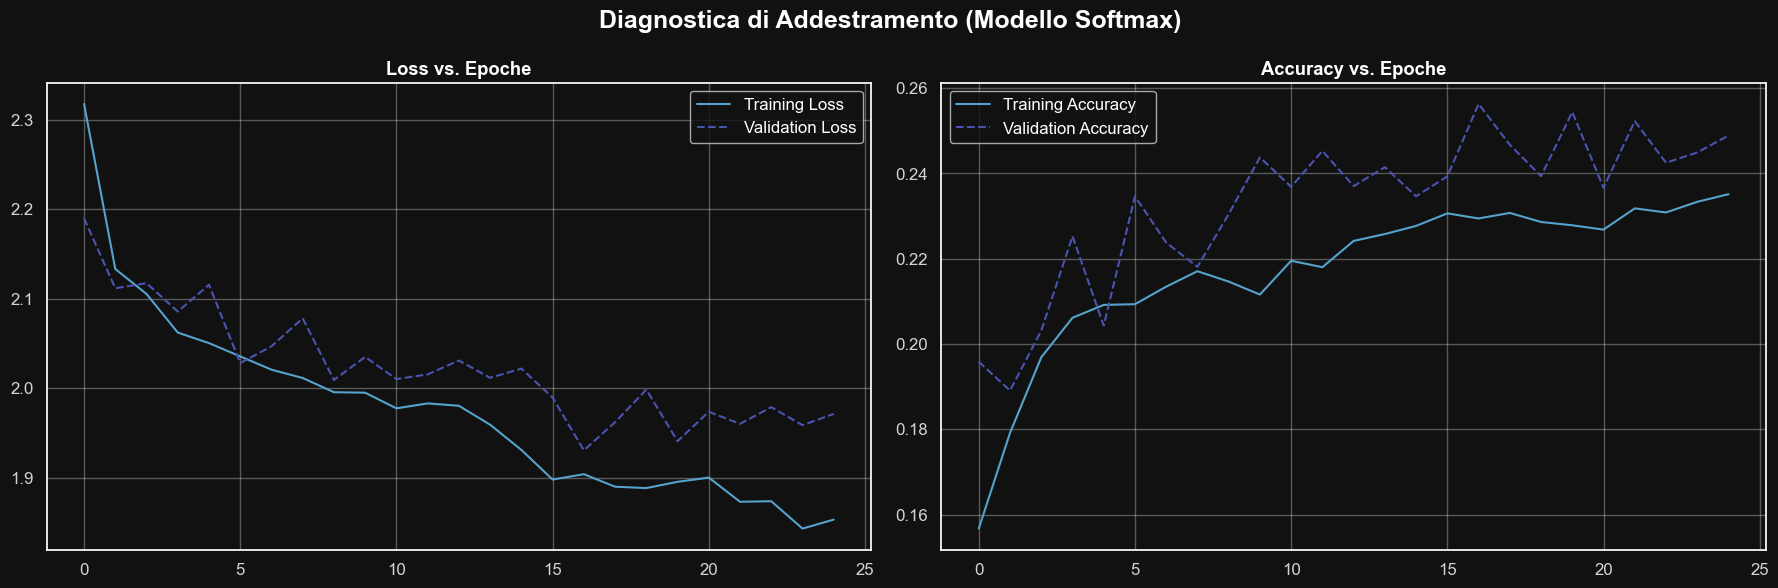

928/928 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- Report di Classificazione (Rete Neurale Softmax) ---
              precision    recall  f1-score   support

      (0, 1]       0.01      0.50      0.01        18
      (1, 2]       0.02      0.33      0.04        94
      (2, 3]       0.05      0.18      0.08       236
      (3, 4]       0.09      0.24      0.13       686
      (4, 5]       0.23      0.28      0.25      1812
      (5, 6]       0.31      0.26      0.28      4243
      (6, 7]       0.41      0.12      0.19      7745
      (7, 8]       0.53      0.35      0.42      9627
      (8, 9]       0.23      0.24      0.24      4372
     (9, 10]       0.09      0.51      0.15       854

    accuracy                           0.26     29687
   macro avg       0.20      0.30      0.18     29687
weighted avg       0.38      0.26      0.28     29687


--- Matrice di Confusione (Formato Testuale) ---
[[   9    7    0    0    0    0    0    0    1    1]
 [  18   31   12    8    5    2    2   

/var/folders/4l/s_d8z1kx7h762hwfcv4xhtsh0000gn/T/ipykernel_6859/3148107747.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)



✅ Grafico di valutazione 1x2 per Rete Neurale Softmax salvato in: plots_advanced_classification_xai/09_nn_softmax_full_evaluation.png


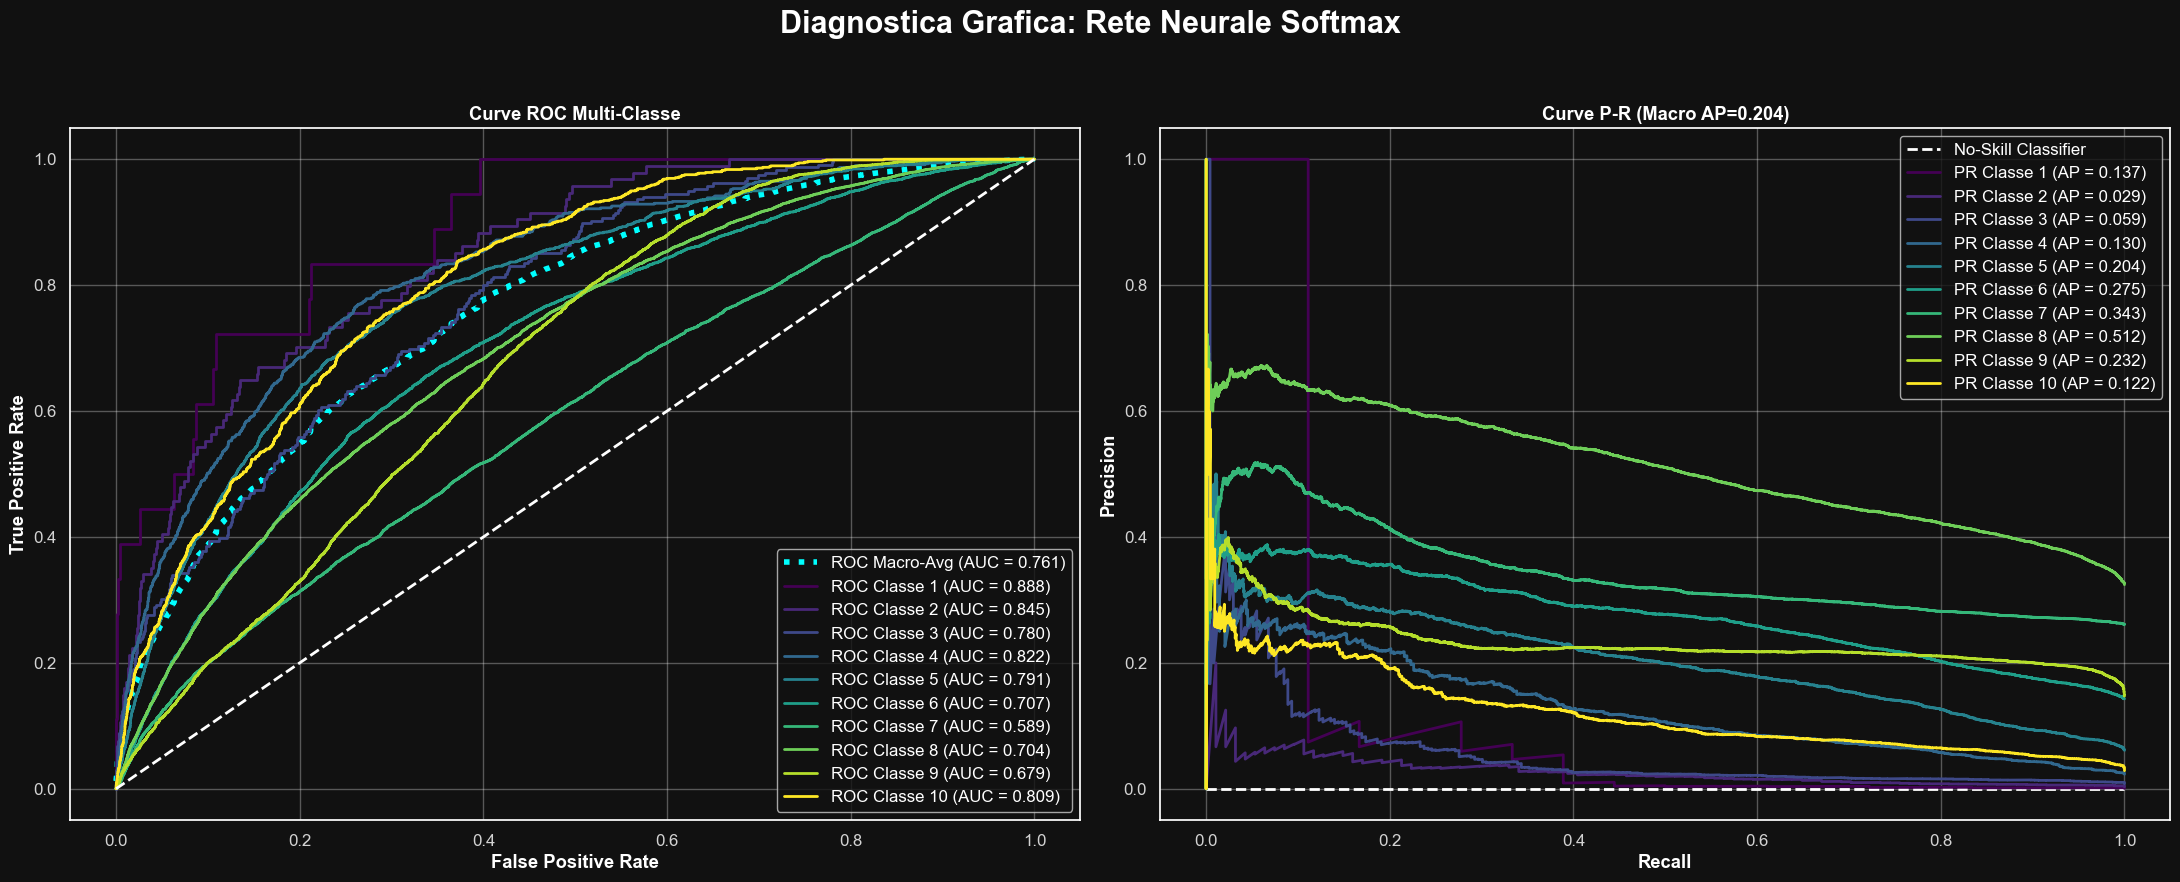

In [17]:
# %%
# OBIETTIVO:
# Eseguire la valutazione completa del modello di rete neurale Softmax,
# includendo la cronologia di addestramento e il nostro plot 1x2 standard.

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from itertools import cycle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Valutazione Completa: Rete Neurale Softmax Definitiva ---")

# --- BLOCCO DI SICUREZZA ---
print("[INFO] Setup di sicurezza: ricaricamento di LabelEncoder e dati encodati...")
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded = label_encoder.transform(y_test)
print("✅ Variabili di valutazione pronte.")
# --- FINE BLOCCO DI SICUREZZA ---


# --- 1. CRONOLOGIA DI ADDESTRAMENTO ---
history_df_softmax = pd.DataFrame(history_softmax.history)
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(18, 6))
fig_hist.suptitle('Diagnostica di Addestramento (Modello Softmax)', fontsize=18, weight='bold')
# ... (codice plot cronologia)
axes_hist[0].plot(history_df_softmax['loss'], label='Training Loss')
axes_hist[0].plot(history_df_softmax['val_loss'], label='Validation Loss', linestyle='--')
axes_hist[0].set_title('Loss vs. Epoche'); axes_hist[0].legend(); axes_hist[0].grid(True, alpha=0.3)
axes_hist[1].plot(history_df_softmax['accuracy'], label='Training Accuracy')
axes_hist[1].plot(history_df_softmax['val_accuracy'], label='Validation Accuracy', linestyle='--')
axes_hist[1].set_title('Accuracy vs. Epoche'); axes_hist[1].legend(); axes_hist[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir + 'loss_accuracy_epoche.png', dpi=300)

plt.show()


# --- 2. PREDIZIONI E REPORT TESTUALE ---
y_prob_nn = best_nn_model.predict(X_test)
y_pred_nn_encoded = np.argmax(y_prob_nn, axis=-1)
class_labels_text = label_encoder.classes_

print("\n--- Report di Classificazione (Rete Neurale Softmax) ---")
print(classification_report(y_test_encoded, y_pred_nn_encoded, target_names=class_labels_text, zero_division=0))
print("\n--- Matrice di Confusione (Formato Testuale) ---")
print(confusion_matrix(y_test_encoded, y_pred_nn_encoded))


# --- 3. GRAFICO 1x2 (ROC e PR) ---
y_test_bin_encoded = LabelBinarizer().fit_transform(y_test_encoded)
n_classes = y_test_bin_encoded.shape[1]
fpr_nn, tpr_nn, roc_auc_nn = {}, {}, {}; precision_nn, recall_nn, avg_precision_nn = {}, {}, {}
# ... (calcoli per le curve)
for i in range(n_classes):
    fpr_nn[i], tpr_nn[i], _ = roc_curve(y_test_bin_encoded[:, i], y_prob_nn[:, i])
    roc_auc_nn[i] = auc(fpr_nn[i], tpr_nn[i])
    precision_nn[i], recall_nn[i], _ = precision_recall_curve(y_test_bin_encoded[:, i], y_prob_nn[:, i])
    avg_precision_nn[i] = average_precision_score(y_test_bin_encoded[:, i], y_prob_nn[:, i])
all_fpr_nn = np.unique(np.concatenate([fpr_nn[i] for i in range(n_classes)])); mean_tpr_nn = np.zeros_like(all_fpr_nn)
for i in range(n_classes): mean_tpr_nn += np.interp(all_fpr_nn, fpr_nn[i], tpr_nn[i])
mean_tpr_nn /= n_classes; fpr_nn["macro"] = all_fpr_nn; tpr_nn["macro"] = mean_tpr_nn; roc_auc_nn["macro"] = auc(fpr_nn["macro"], tpr_nn["macro"])
avg_prec_macro_nn = average_precision_score(y_test_bin_encoded, y_prob_nn, average='macro')


fig_nn, axes_nn = plt.subplots(1, 2, figsize=(22, 9))
fig_nn.suptitle('Diagnostica Grafica: Rete Neurale Softmax', fontsize=22, weight='bold')
colors = cycle(plt.cm.get_cmap('viridis', n_classes).colors)

# Plot ROC
axes_nn[0].plot(fpr_nn["macro"], tpr_nn["macro"], label=f'ROC Macro-Avg (AUC = {roc_auc_nn["macro"]:.3f})', color='cyan', linestyle=':', linewidth=4)
for i, color in zip(range(n_classes), colors): axes_nn[0].plot(fpr_nn[i], tpr_nn[i], color=color, lw=2, label=f'ROC Classe {i+1} (AUC = {roc_auc_nn[i]:.3f})')
axes_nn[0].plot([0, 1], [0, 1], 'w--', lw=2); axes_nn[0].set_title('Curve ROC Multi-Classe'); axes_nn[0].legend(loc="lower right"); axes_nn[0].grid(True, alpha=0.3)
axes_nn[0].set_xlabel('False Positive Rate'); axes_nn[0].set_ylabel('True Positive Rate')

# Plot PR
axes_nn[1].plot([0, 1], [n_classes/y_test_bin_encoded.sum(), n_classes/y_test_bin_encoded.sum()], 'w--', lw=2, label='No-Skill Classifier')
for i, color in zip(range(n_classes), colors): axes_nn[1].plot(recall_nn[i], precision_nn[i], color=color, lw=2, label=f'PR Classe {i+1} (AP = {avg_precision_nn[i]:.3f})')
axes_nn[1].set_title(f'Curve P-R (Macro AP={avg_prec_macro_nn:.3f})'); axes_nn[1].legend(loc="best"); axes_nn[1].grid(True, alpha=0.3)
axes_nn[1].set_xlabel('Recall'); axes_nn[1].set_ylabel('Precision')

plt.tight_layout(rect=(0, 0, 1, 0.95))
plot_path_nn = os.path.join(plots_dir, '09_nn_softmax_full_evaluation.png')
plt.savefig(plot_path_nn, dpi=300)
print(f"\n✅ Grafico di valutazione 1x2 per Rete Neurale Softmax salvato in: {plot_path_nn}")
plt.show()

### REGRESSIONE: Rete Neurale Avanzata con Regolarizzazione

In [ ]:
# %%
# OBIETTIVO:
# Costruire e addestrare la rete neurale "definitiva" che affronta il problema
# come una REGRESSIONE, utilizzando l'architettura ottimizzata.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer, GaussianNoise, ReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("--- [MODELLO DEFINITIVO] Inizio Processo per Rete Neurale a REGRESSIONE ---")

# --- FASE 1: PREPARAZIONE DATI ---
# Assumiamo che X_train, y_train_encoded, INPUT_SHAPE, e N_CLASSES
# siano già state definite nelle celle precedenti.
print("✅ Dati pronti per il training del modello a regressione.")


# --- FASE 2: DEFINIZIONE DELL'ARCHITETTURA A REGRESSIONE ---
print("\n[FASE 2] Costruzione dell'architettura della Rete Neurale a Regressione...")

model_regression = Sequential([
    InputLayer(input_shape=INPUT_SHAPE),
    GaussianNoise(0.15),

    Dense(512, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Dropout(0.5),

    Dense(256, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),

    Dense(128, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Dropout(0.3),

    Dense(64, kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),

    Dense(1, activation='linear')  # Output regressivo
], name='Definitive_Regression_MLP')

# Compiliamo il modello con loss MSE e metrica MAE
model_regression.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mean_squared_error',
    metrics=['mean_absolute_error'] # MAE è più interpretabile
)

model_regression.summary()


# --- FASE 3: ADDESTRAMENTO ---
print("\n[FASE 3] Inizio Addestramento del Modello a Regressione...")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_regressor_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1)

history_reg = model_regression.fit(
    X_train, y_train_encoded,
    validation_split=0.2,
    epochs=70,
    batch_size=128,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# Salviamo il modello finale per la valutazione
best_nn_model = model_regression

print("\n✅ Addestramento del modello a regressione completato.")

#### Regressione Valutazione Rete Neurale Avanzata

In [ ]:
# %%
# OBIETTIVO:
# Eseguire una valutazione completa del modello a regressione, calcolando
# sia le metriche di regressione (MAE, RMSE) sia le metriche di classificazione
# dopo aver arrotondato le predizioni.

from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- Valutazione Completa: Rete Neurale a Regressione ---")

# --- BLOCCO DI SICUREZZA ---
# Rende la cella autosufficiente per prevenire errori di scope.
print("[INFO] Setup di sicurezza: ricaricamento di LabelEncoder e y_test_encoded...")
label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_test_encoded = label_encoder.transform(y_test)
print("✅ Variabili di valutazione pronte.")
# --- FINE BLOCCO DI SICUREZZA ---


# --- 1. CRONOLOGIA DI ADDESTRAMENTO ---
history_df_reg = pd.DataFrame(history_reg.history)
fig_hist_reg, axes_hist_reg = plt.subplots(1, 2, figsize=(18, 6))
fig_hist_reg.suptitle('Diagnostica di Addestramento (Modello a Regressione)', fontsize=18, weight='bold')

# Grafico della Loss (MSE)
axes_hist_reg[0].plot(history_df_reg['loss'], label='Training Loss (MSE)')
axes_hist_reg[0].plot(history_df_reg['val_loss'], label='Validation Loss (MSE)', linestyle='--')
axes_hist_reg[0].set_title('Loss (MSE) vs. Epoche'); axes_hist_reg[0].legend(); axes_hist_reg[0].grid(True, alpha=0.3)
# Grafico della Metrica (MAE)
axes_hist_reg[1].plot(history_df_reg['mean_absolute_error'], label='Training MAE')
axes_hist_reg[1].plot(history_df_reg['val_mean_absolute_error'], label='Validation MAE', linestyle='--')
axes_hist_reg[1].set_title('Mean Absolute Error vs. Epoche'); axes_hist_reg[1].legend(); axes_hist_reg[1].grid(True, alpha=0.3)
plt.show()


# --- 2. PREDIZIONI E VALUTAZIONE DI REGRESSIONE ---
print("\n--- Valutazione di Regressione (Metriche Principali) ---")
y_pred_reg = best_nn_model.predict(X_test).ravel() # Predizione continua (float)

# Calcoliamo le metriche di regressione
mae = mean_absolute_error(y_test_encoded, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_encoded, y_pred_reg))

print(f"Mean Absolute Error (MAE) sul Test Set: {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) sul Test Set: {rmse:.4f}")
print("\nINTERPRETAZIONE: In media, le predizioni del modello si discostano dal voto reale (in scala 0-9) di circa " + f"{mae:.2f} punti.")


# --- 3. VALUTAZIONE DI CLASSIFICAZIONE (DOPO ARROTONDAMENTO) ---
print("\n--- Valutazione di Classificazione (dopo arrotondamento) ---")

# Arrotondiamo e clippiamo per ottenere le classi finali
y_pred_classes = np.clip(np.round(y_pred_reg), 0, 9).astype(int)
class_labels_text = label_encoder.classes_

# Report e Matrice di Confusione
print("\n--- Report di Classificazione ---")
print(classification_report(y_test_encoded, y_pred_classes, target_names=class_labels_text, zero_division=0))
print("\n--- Matrice di Confusione (Formato Testuale) ---")
print(confusion_matrix(y_test_encoded, y_pred_classes))

## FASE DI EXPLAINABILITY

In [9]:
# ==========================================
# CARICAMENTO MODELLO RandomForestClassifier
# ==========================================
print("Carico il modello Random-Forest Classifier")
model_name = "random_forest_model.joblib"
model_path = models_dir + model_name
best_rf_model = joblib.load(model_path)
if best_rf_model is not None:
    print(f"Modello Random Forest {model_path} caricato con successo!")
else:
    print(f"Errore nel caricamento del modello {model_path}")

Carico il modello Random-Forest Classifier
Modello Random Forest models_classification/random_forest_model.joblib caricato con successo!


### EXPLAINABLE AI con SHAP per RandomForestClassifier

In [18]:
# %% CELLA 1: CALCOLI SHAP
import shap
import pandas as pd
import numpy as np
import os
import joblib

print("--- INIZIO CALCOLO SHAP ---")

# --- 1. SETUP ---
sample_quantity = 100

if 'best_rf_model' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    raise ValueError("Dati o modello non trovati. Eseguire le celle di addestramento precedenti.")

# --- 2. PREPARAZIONE DATI ---
X_test_sample = X_test.sample(n=sample_quantity, random_state=999)
class_labels = best_rf_model.classes_.tolist()

print(f"Calcolo dei valori SHAP per {sample_quantity} campioni...")

# --- 3. CALCOLO SHAP ---
explainer = shap.TreeExplainer(best_rf_model)

# Calcolo valori SHAP - metodo compatibile con versioni recenti
shap_values = explainer(X_test_sample, check_additivity=False)

# Estrazione dei componenti necessari
if hasattr(shap_values, 'values'):
    # Nuova versione SHAP (>= 0.40)
    shap_values_array = shap_values.values
    expected_values = shap_values.base_values
else:
    # Versione più vecchia - fallback
    shap_values_array = explainer.shap_values(X_test_sample)
    expected_values = explainer.expected_value

# --- 4. NORMALIZZAZIONE FORMATO ---
# Assicuriamoci che i dati siano nel formato corretto
if isinstance(shap_values_array, list):
    # Multi-classe: lista di array
    shap_values_list = shap_values_array
else:
    # Singola classe o formato diverso
    if len(shap_values_array.shape) == 3:
        # Formato (n_samples, n_features, n_classes)
        shap_values_list = [shap_values_array[:, :, i] for i in range(shap_values_array.shape[2])]
    else:
        # Formato (n_samples, n_features) - classificazione binaria
        shap_values_list = [shap_values_array]

# Normalizzazione expected values
if isinstance(expected_values, np.ndarray):
    if expected_values.ndim == 1 and len(expected_values) == len(class_labels):
        explainer_expected_value = expected_values
    else:
        explainer_expected_value = expected_values.mean(axis=0) if expected_values.ndim > 1 else [expected_values.mean()]
else:
    explainer_expected_value = expected_values if isinstance(expected_values, list) else [expected_values]

# --- 5. VERIFICA CONSISTENZA ---
print(f"Numero di classi: {len(class_labels)}")
print(f"Forma valori SHAP per classe: {[arr.shape for arr in shap_values_list]}")
print(f"Expected values: {explainer_expected_value}")

# --- 6. SALVATAGGIO ---
cache_dir = "shap_cache"
os.makedirs(cache_dir, exist_ok=True)

# Salvataggio dati
joblib.dump(shap_values_list, os.path.join(cache_dir, "shap_values_list.pkl"))
joblib.dump(explainer_expected_value, os.path.join(cache_dir, "explainer_expected_value.pkl"))
joblib.dump(X_test_sample, os.path.join(cache_dir, "X_test_sample.pkl"))
joblib.dump(class_labels, os.path.join(cache_dir, "class_labels.pkl"))
joblib.dump(y_test, os.path.join(cache_dir, "y_test.pkl"))

print("\n--- CALCOLO COMPLETATO E DATI SALVATI ---")
print("Le variabili necessarie sono state salvate in 'shap_cache/'")
print("Esegui la Cella 2 per generare i grafici.")

--- INIZIO CALCOLO SHAP ---
Calcolo dei valori SHAP per 100 campioni...
Numero di classi: 10
Forma valori SHAP per classe: [(100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85)]
Expected values: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

--- CALCOLO COMPLETATO E DATI SALVATI ---
Le variabili necessarie sono state salvate in 'shap_cache/'
Esegui la Cella 2 per generare i grafici.


### Caricamento dati SHAP

In [19]:
# %% CELLA 1B: CARICAMENTO CACHE SHAP (ALTERNATIVA ALLA CELLA 1)
import joblib
import os
import pandas as pd
import numpy as np

print("--- CARICAMENTO DATI SHAP DA CACHE ---")

# --- 1. VERIFICA ESISTENZA CACHE ---
cache_dir = "shap_cache"
required_files = [
    "shap_values_list.pkl",
    "explainer_expected_value.pkl",
    "X_test_sample.pkl",
    "class_labels.pkl",
    "y_test.pkl"
]

# Controllo presenza file
missing_files = []
for file in required_files:
    file_path = os.path.join(cache_dir, file)
    if not os.path.exists(file_path):
        missing_files.append(file)

if missing_files:
    print(f"❌ ERRORE: File mancanti nella cache: {missing_files}")
    print("Eseguire prima la Cella 1 per generare i dati SHAP.")
    raise FileNotFoundError(f"Cache incompleta. File mancanti: {missing_files}")

# --- 2. CARICAMENTO VARIABILI ---
try:
    print("Caricamento in corso...")

    # Caricamento dati principali
    shap_values_list = joblib.load(os.path.join(cache_dir, "shap_values_list.pkl"))
    explainer_expected_value = joblib.load(os.path.join(cache_dir, "explainer_expected_value.pkl"))
    X_test_sample = joblib.load(os.path.join(cache_dir, "X_test_sample.pkl"))
    class_labels = joblib.load(os.path.join(cache_dir, "class_labels.pkl"))
    y_test = joblib.load(os.path.join(cache_dir, "y_test.pkl"))

    print("✅ Tutti i file caricati con successo!")

except Exception as e:
    print(f"❌ Errore durante il caricamento: {e}")
    print("Verifica che i file nella cache siano integri o riesegui la Cella 1.")
    raise

# --- 3. VERIFICA INTEGRITÀ DATI ---
print("\n--- VERIFICA INTEGRITÀ DATI ---")

# Controlli di consistenza
print(f"📊 Dimensioni campione test: {X_test_sample.shape}")
print(f"🎯 Numero classi: {len(class_labels)}")
print(f"📈 Classi disponibili: {class_labels}")
print(f"🔢 Forma valori SHAP: {[arr.shape for arr in shap_values_list]}")
print(f"⚖️  Expected values: {explainer_expected_value}")

# Verifica coerenza dimensioni
expected_samples = X_test_sample.shape[0]
expected_features = X_test_sample.shape[1]
expected_classes = len(class_labels)

# Controllo SHAP values
if len(shap_values_list) != expected_classes:
    print("⚠️  WARNING: Numero di array SHAP non corrisponde al numero di classi")
else:
    print("✅ Numero classi coerente")

# Controllo dimensioni SHAP
for i, shap_array in enumerate(shap_values_list):
    if shap_array.shape != (expected_samples, expected_features):
        print(f"⚠️  WARNING: Dimensioni SHAP per classe {i} non corrette: {shap_array.shape}")
    else:
        print(f"✅ Dimensioni SHAP classe {class_labels[i]}: OK")

# Controllo y_test
if len(y_test) != len(X_test_sample):
    print(f"⚠️  WARNING: Lunghezza y_test ({len(y_test)}) != campioni ({len(X_test_sample)})")
else:
    print("✅ Dimensioni y_test coerenti")

print("\n--- CARICAMENTO COMPLETATO ---")
print("🚀 Le variabili sono pronte per la Cella 2 (Grafici)")
print("\nVariabili disponibili:")
print("- shap_values_list: valori SHAP per tutte le classi")
print("- explainer_expected_value: valori base del modello")
print("- X_test_sample: campione di test utilizzato")
print("- class_labels: etichette delle classi")
print("- y_test: etichette vere del test set")

--- CARICAMENTO DATI SHAP DA CACHE ---
Caricamento in corso...
✅ Tutti i file caricati con successo!

--- VERIFICA INTEGRITÀ DATI ---
📊 Dimensioni campione test: (100, 85)
🎯 Numero classi: 10
📈 Classi disponibili: ['(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]', '(5, 6]', '(6, 7]', '(7, 8]', '(8, 9]', '(9, 10]']
🔢 Forma valori SHAP: [(100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85), (100, 85)]
⚖️  Expected values: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
✅ Numero classi coerente
✅ Dimensioni SHAP classe (0, 1]: OK
✅ Dimensioni SHAP classe (1, 2]: OK
✅ Dimensioni SHAP classe (2, 3]: OK
✅ Dimensioni SHAP classe (3, 4]: OK
✅ Dimensioni SHAP classe (4, 5]: OK
✅ Dimensioni SHAP classe (5, 6]: OK
✅ Dimensioni SHAP classe (6, 7]: OK
✅ Dimensioni SHAP classe (7, 8]: OK
✅ Dimensioni SHAP classe (8, 9]: OK
✅ Dimensioni SHAP classe (9, 10]: OK
⚠️  WARNING: Lunghezza y_test (29687) != campioni (100)

--- CARICAMENTO COMPLETATO ---
🚀 Le variabili 

#### troviamo le isrtanze più interessanti

In [20]:
# %% TROVA ISTANZE BILANCIATE (BLU/ROSSO)
import numpy as np
import pandas as pd
import joblib
import os

print("🔍 RICERCA ISTANZE CON PERFETTO BILANCIAMENTO BLU/ROSSO")
print("="*60)

# Carica dati
cache_dir = "shap_cache"
shap_values_list = joblib.load(os.path.join(cache_dir, "shap_values_list.pkl"))
X_test_sample = joblib.load(os.path.join(cache_dir, "X_test_sample.pkl"))
y_test = joblib.load(os.path.join(cache_dir, "y_test.pkl"))
class_labels = joblib.load(os.path.join(cache_dir, "class_labels.pkl"))

# Analizza TUTTE le istanze di TUTTE le classi
perfect_instances = []

print("🔍 Scansionando tutto il dataset...")

for class_idx, class_name in enumerate(class_labels):
    shap_vals = shap_values_list[class_idx]

    for instance_idx in range(len(shap_vals)):
        instance_shap = shap_vals[instance_idx]

        # Conta contributi positivi e negativi
        positive_values = instance_shap[instance_shap > 0]
        negative_values = instance_shap[instance_shap < 0]

        if len(positive_values) > 0 and len(negative_values) > 0:
            # Calcola forze
            pos_strength = np.sum(positive_values)
            neg_strength = np.abs(np.sum(negative_values))

            # Balance ratio (quanto sono bilanciati)
            balance = min(pos_strength, neg_strength) / max(pos_strength, neg_strength)

            # Conta feature
            pos_count = len(positive_values)
            neg_count = len(negative_values)
            feature_balance = min(pos_count, neg_count) / max(pos_count, neg_count)

            # Score complessivo
            overall_score = balance * feature_balance

            # Solo istanze MOLTO bilanciate
            if balance > 0.4 and feature_balance > 0.3 and overall_score > 0.2:
                # Predizioni
                predicted_class = best_rf_model.predict([X_test_sample.iloc[instance_idx]])[0]
                true_class = y_test.iloc[instance_idx] if hasattr(y_test, 'iloc') else y_test[instance_idx]

                perfect_instances.append({
                    'instance_idx': instance_idx,
                    'class_name': class_name,
                    'predicted_class': predicted_class,
                    'true_class': true_class,
                    'pos_features': pos_count,
                    'neg_features': neg_count,
                    'pos_strength': pos_strength,
                    'neg_strength': neg_strength,
                    'balance_ratio': balance,
                    'feature_balance': feature_balance,
                    'overall_score': overall_score,
                    'total_shap': instance_shap.sum()
                })

# Ordina per bilanciamento
perfect_instances.sort(key=lambda x: x['overall_score'], reverse=True)

print(f"\n🎯 TROVATE {len(perfect_instances)} ISTANZE PERFETTAMENTE BILANCIATE!")
print("="*60)

if len(perfect_instances) > 0:
    print("\n🏆 TOP 10 ISTANZE CON PERFETTO MIX BLU/ROSSO:")
    print("-" * 60)

    for i, inst in enumerate(perfect_instances[:10]):
        pos_pct = (inst['pos_strength'] / (inst['pos_strength'] + inst['neg_strength'])) * 100
        neg_pct = 100 - pos_pct

        print(f"🎯 #{i+1}: ISTANZA {inst['instance_idx']}")
        print(f"   💪 Forza: {pos_pct:.1f}% BLU vs {neg_pct:.1f}% ROSSO")
        print(f"   📊 Feature: {inst['pos_features']} positive, {inst['neg_features']} negative")
        print(f"   🏷️  Vera: {inst['true_class']} → Predetta: {inst['predicted_class']}")
        print(f"   ⚖️  Balance Score: {inst['overall_score']:.3f}")
        print(f"   📈 SHAP totale: {inst['total_shap']:+.3f}")
        print()

    # RACCOMANDAZIONI SPECIFICHE
    print("🎨 ISTANZE CONSIGLIATE PER GRAFICI SPETTACOLARI:")
    print("="*60)

    best_instances = perfect_instances[:5]
    for inst in best_instances:
        pos_pct = (inst['pos_strength'] / (inst['pos_strength'] + inst['neg_strength'])) * 100
        neg_pct = 100 - pos_pct

        print(f"✨ INSTANCE_TO_ANALYZE = {inst['instance_idx']}")
        print(f"   🎨 Mix perfetto: {pos_pct:.1f}% BLU + {neg_pct:.1f}% ROSSO")
        print(f"   📝 Commento: Classe {inst['predicted_class']}, bilanciamento {inst['balance_ratio']:.2f}")
        print()

    print("💡 COPIA UNO DI QUESTI NUMERI NELLA CELLA 2!")
    print(f"   INSTANCE_TO_ANALYZE = {perfect_instances[0]['instance_idx']}  # ← IL MIGLIORE!")

else:
    print("😞 NESSUNA ISTANZA PERFETTAMENTE BILANCIATA TROVATA")
    print("\n🔍 Provo con criteri meno rigidi...")

    # Seconda passata con criteri più rilassati
    relaxed_instances = []

    for class_idx, class_name in enumerate(class_labels):
        shap_vals = shap_values_list[class_idx]

        for instance_idx in range(len(shap_vals)):
            instance_shap = shap_vals[instance_idx]

            positive_values = instance_shap[instance_shap > 0]
            negative_values = instance_shap[instance_shap < 0]

            if len(positive_values) > 0 and len(negative_values) > 0:
                pos_strength = np.sum(positive_values)
                neg_strength = np.abs(np.sum(negative_values))
                balance = min(pos_strength, neg_strength) / max(pos_strength, neg_strength)

                # Criteri più rilassati
                if balance > 0.2:
                    predicted_class = best_rf_model.predict([X_test_sample.iloc[instance_idx]])[0]
                    true_class = y_test.iloc[instance_idx] if hasattr(y_test, 'iloc') else y_test[instance_idx]

                    relaxed_instances.append({
                        'instance_idx': instance_idx,
                        'predicted_class': predicted_class,
                        'true_class': true_class,
                        'balance_ratio': balance,
                        'pos_strength': pos_strength,
                        'neg_strength': neg_strength
                    })

    relaxed_instances.sort(key=lambda x: x['balance_ratio'], reverse=True)

    if len(relaxed_instances) > 0:
        print(f"\n🎯 TROVATE {len(relaxed_instances)} ISTANZE CON BILANCIAMENTO DECENTE:")
        print("-" * 50)

        for i, inst in enumerate(relaxed_instances[:5]):
            pos_pct = (inst['pos_strength'] / (inst['pos_strength'] + inst['neg_strength'])) * 100
            neg_pct = 100 - pos_pct

            print(f"⚖️  INSTANCE_TO_ANALYZE = {inst['instance_idx']}")
            print(f"   Mix: {pos_pct:.1f}% BLU + {neg_pct:.1f}% ROSSO")
            print(f"   Balance: {inst['balance_ratio']:.3f}")
            print()

    else:
        print("💥 IL TUO DATASET È ESTREMAMENTE SBILANCIATO!")
        print("   Tutte le istanze hanno contributi nella stessa direzione")
        print("   Prova a cambiare random_state nella Cella 1 per diversità")

print("\n" + "="*60)

🔍 RICERCA ISTANZE CON PERFETTO BILANCIAMENTO BLU/ROSSO
🔍 Scansionando tutto il dataset...


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names,


🎯 TROVATE 229 ISTANZE PERFETTAMENTE BILANCIATE!

🏆 TOP 10 ISTANZE CON PERFETTO MIX BLU/ROSSO:
------------------------------------------------------------
🎯 #1: ISTANZA 52
   💪 Forza: 49.6% BLU vs 50.4% ROSSO
   📊 Feature: 43 positive, 42 negative
   🏷️  Vera: (6, 7] → Predetta: (5, 6]
   ⚖️  Balance Score: 0.963
   📈 SHAP totale: -0.001

🎯 #2: ISTANZA 5
   💪 Forza: 49.6% BLU vs 50.4% ROSSO
   📊 Feature: 42 positive, 43 negative
   🏷️  Vera: (6, 7] → Predetta: (6, 7]
   ⚖️  Balance Score: 0.960
   📈 SHAP totale: -0.002

🎯 #3: ISTANZA 80
   💪 Forza: 49.5% BLU vs 50.5% ROSSO
   📊 Feature: 42 positive, 43 negative
   🏷️  Vera: (8, 9] → Predetta: (8, 9]
   ⚖️  Balance Score: 0.956
   📈 SHAP totale: -0.003

🎯 #4: ISTANZA 8
   💪 Forza: 50.9% BLU vs 49.1% ROSSO
   📊 Feature: 43 positive, 42 negative
   🏷️  Vera: (6, 7] → Predetta: (8, 9]
   ⚖️  Balance Score: 0.944
   📈 SHAP totale: +0.003

🎯 #5: ISTANZA 28
   💪 Forza: 51.3% BLU vs 48.7% ROSSO
   📊 Feature: 42 positive, 43 negative
   🏷️  Ve

/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names,

### GRAFICI SHAP

🚀 GENERAZIONE GRAFICI SHAP
✅ Dati caricati con successo

1️⃣ GLOBAL ANALYSIS - Beeswarm Plot


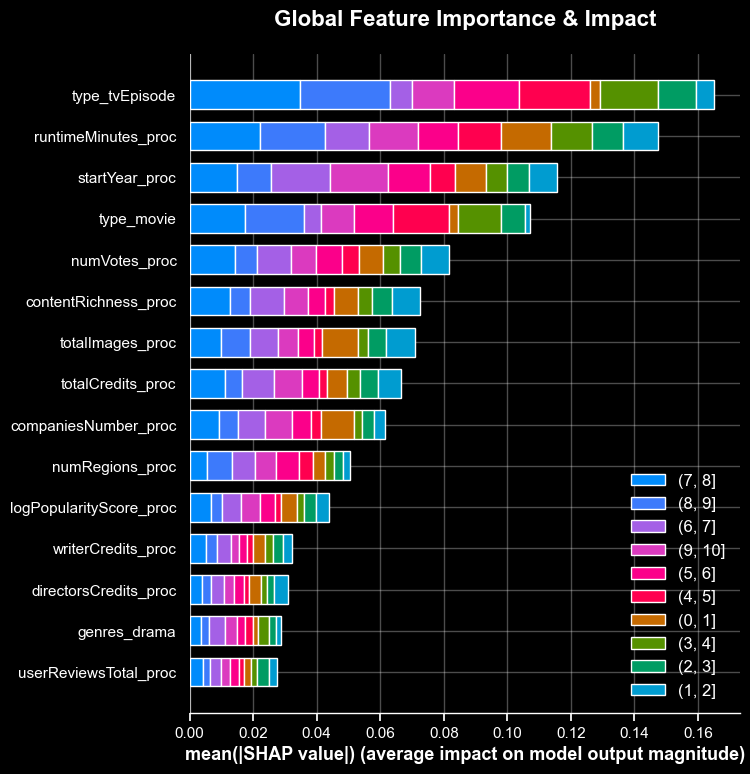

   → 01_global_beeswarm.png salvato

2️⃣ WATERFALL PLOT
   Istanza 52: Vera=(6, 7], Predetta=(5, 6]


/opt/anaconda3/envs/dm2_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


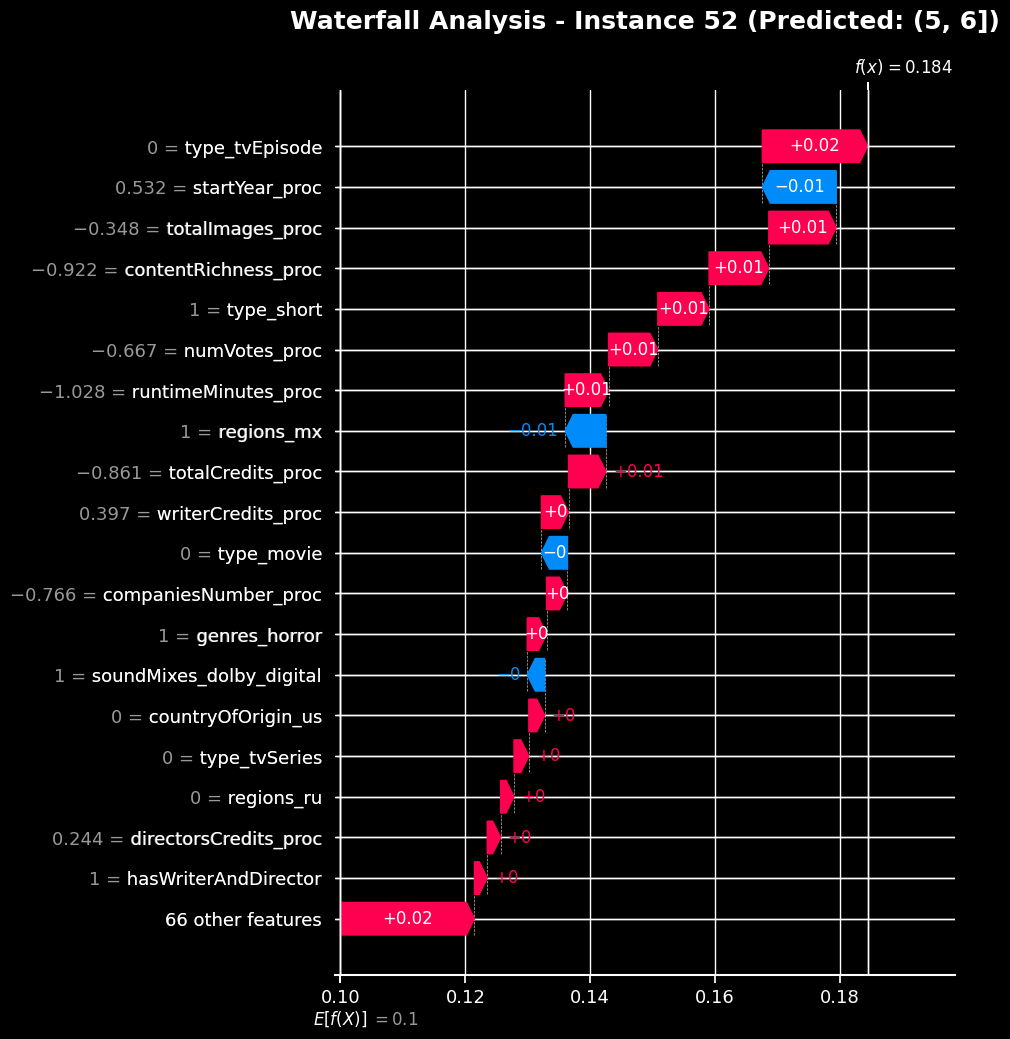

   → 02_waterfall.png salvato
   ✅ Waterfall generato!

3️⃣ DECISION PLOT


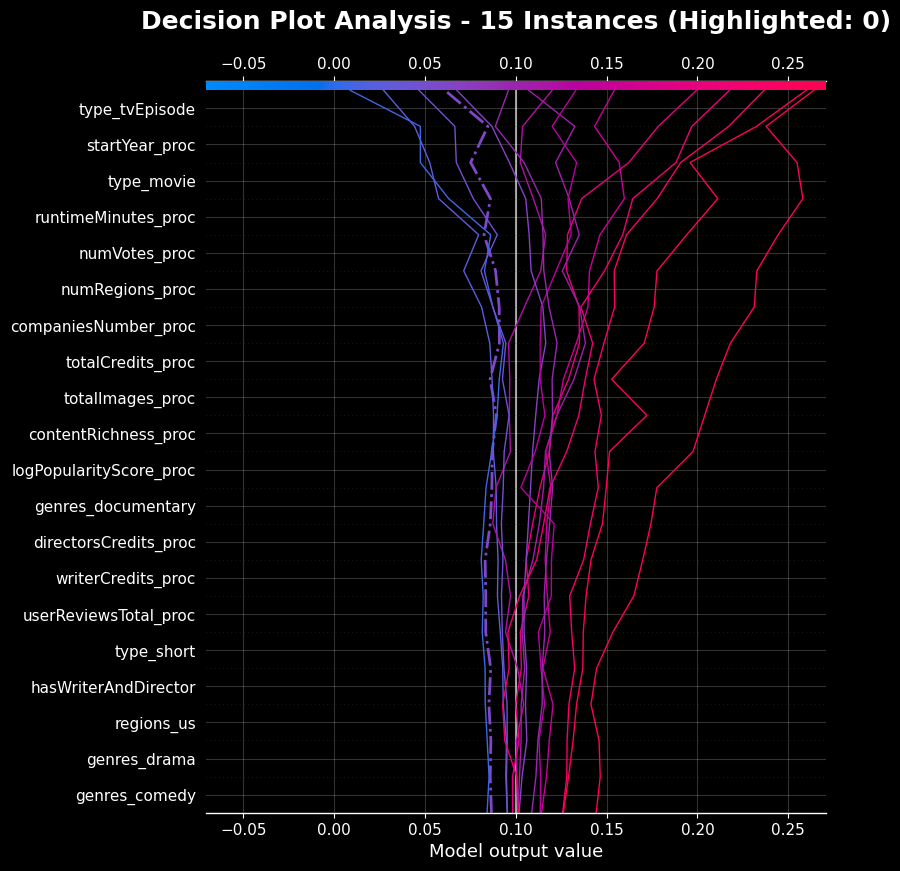

   → 03_decision.png salvato
   ✅ Decision plot generato!

✅ GRAFICI GENERATI (3 ESSENZIALI):
   1️⃣ Global Beeswarm → Panoramica feature
   2️⃣ Waterfall Plot → Analisi locale dettagliata
   3️⃣ Decision Plot → Confronto multi-istanza

📁 Salvati in: plots_advanced_classification_xai/random_forest_explainability/
🎯 Istanza analizzata: 52
🎨 TUTTI I GRAFICI CON STYLING PERFETTO!


In [21]:
# %% CELLA 2: GRAFICI SHAP SEMPLICI
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

print("🚀 GENERAZIONE GRAFICI SHAP")

# ===============================================
# 📂 CARICAMENTO DATI
# ===============================================
cache_dir = "shap_cache"
if not os.path.exists(cache_dir):
    raise ValueError("❌ Cache non trovata. Eseguire prima la Cella 1.")

try:
    shap_values_list = joblib.load(os.path.join(cache_dir, "shap_values_list.pkl"))
    explainer_expected_value = joblib.load(os.path.join(cache_dir, "explainer_expected_value.pkl"))
    X_test_sample = joblib.load(os.path.join(cache_dir, "X_test_sample.pkl"))
    class_labels = joblib.load(os.path.join(cache_dir, "class_labels.pkl"))
    y_test = joblib.load(os.path.join(cache_dir, "y_test.pkl"))
    print("✅ Dati caricati con successo")
except Exception as e:
    raise ValueError(f"❌ Errore: {e}")

# Setup
plots_dir = "plots_advanced_classification_xai/random_forest_explainability/"
os.makedirs(plots_dir, exist_ok=True)

# ISTANZA DA ANALIZZARE (CAMBIA QUI!)
INSTANCE_TO_ANALYZE = 52

def save_plot(filename):
    plt.savefig(os.path.join(plots_dir, filename), dpi=300, bbox_inches='tight', facecolor='black')
    plt.show()
    plt.close()
    print(f"   → {filename} salvato")

def apply_white_theme():
    """Applica tema bianco completo per massima leggibilità"""
    ax = plt.gca()
    fig = plt.gcf()

    # Sfondo nero
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')

    # Tutti i testi in bianco
    ax.tick_params(colors='white', labelsize=11)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

    # Spine (bordi) bianchi
    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1)

    # Griglia bianca se presente
    ax.grid(True, color='white', alpha=0.3)

    # Tutti i testi nella figura
    for text in ax.texts:
        text.set_color('white')
        text.set_fontweight('normal')

    # Colori specifici per legende
    legend = ax.get_legend()
    if legend:
        legend.get_frame().set_facecolor('black')
        legend.get_frame().set_edgecolor('white')
        for text in legend.get_texts():
            text.set_color('white')

# ===============================================
# 1. GLOBAL BEESWARM PLOT
# ===============================================
print("\n1️⃣ GLOBAL ANALYSIS - Beeswarm Plot")

plt.figure(figsize=(14, 10), facecolor='black')
shap.summary_plot(
    shap_values_list,
    X_test_sample,
    class_names=class_labels,
    max_display=15,
    show=False
)
apply_white_theme()
plt.title("Global Feature Importance & Impact", color='white', fontsize=16, pad=20)
save_plot("01_global_beeswarm.png")

# ===============================================
# 2. WATERFALL PLOT
# ===============================================
print("\n2️⃣ WATERFALL PLOT")

# Selezione istanza
max_available = X_test_sample.shape[0] - 1
instance_index = min(INSTANCE_TO_ANALYZE, max_available)
instance_data = X_test_sample.iloc[instance_index]
true_class = y_test.iloc[instance_index] if hasattr(y_test, 'iloc') else y_test[instance_index]
predicted_class = best_rf_model.predict([instance_data])[0]
predicted_class_idx = class_labels.index(predicted_class)

print(f"   Istanza {instance_index}: Vera={true_class}, Predetta={predicted_class}")

try:
    shap_explanation = shap.Explanation(
        values=np.array(shap_values_list).transpose(1, 2, 0),
        base_values=np.tile(explainer_expected_value, (X_test_sample.shape[0], 1)),
        data=X_test_sample.values,
        feature_names=X_test_sample.columns.tolist()
    )

    plt.style.use('dark_background')
    plt.figure(figsize=(14, 10), facecolor='black')

    shap.plots.waterfall(
        shap_explanation[instance_index, :, predicted_class_idx],
        max_display=20,
        show=False
    )

    # Styling
    ax = plt.gca()
    fig = plt.gcf()
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=12)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

    for text in ax.texts:
        text.set_color('white')
        text.set_fontsize(11)
        text.set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1.5)

    plt.title(f"Waterfall Analysis - Instance {instance_index} (Predicted: {predicted_class})",
              color='white', fontsize=18, fontweight='bold', pad=20)

    plt.style.use('default')
    save_plot("02_waterfall.png")
    print("   ✅ Waterfall generato!")

except Exception as e:
    print(f"   ❌ Waterfall fallito: {e}")

# ===============================================
# 3. DECISION PLOT
# ===============================================
print("\n3️⃣ DECISION PLOT")

try:
    plt.style.use('dark_background')
    plt.figure(figsize=(14, 10), facecolor='black')

    num_instances = min(15, X_test_sample.shape[0])
    highlight_idx = instance_index if instance_index < num_instances else 0

    shap.decision_plot(
        base_value=explainer_expected_value[predicted_class_idx],
        shap_values=shap_values_list[predicted_class_idx][:num_instances],
        features=X_test_sample.iloc[:num_instances],
        show=False,
        highlight=highlight_idx,
        feature_names=X_test_sample.columns.tolist()
    )

    # Styling
    ax = plt.gca()
    fig = plt.gcf()
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    ax.tick_params(colors='white', labelsize=11)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

    for spine in ax.spines.values():
        spine.set_color('white')
        spine.set_linewidth(1)

    for text in ax.texts:
        text.set_color('white')
        text.set_fontweight('normal')

    ax.grid(True, color='white', alpha=0.2)

    plt.title(f"Decision Plot Analysis - {num_instances} Instances (Highlighted: {highlight_idx})",
              color='white', fontsize=18, fontweight='bold', pad=20)

    plt.style.use('default')
    save_plot("03_decision.png")
    print("   ✅ Decision plot generato!")

except Exception as e:
    print(f"   ❌ Decision plot fallito: {e}")

# ===============================================
# SUMMARY
# ===============================================
print("\n" + "="*50)
print("✅ GRAFICI GENERATI (3 ESSENZIALI):")
print("   1️⃣ Global Beeswarm → Panoramica feature")
print("   2️⃣ Waterfall Plot → Analisi locale dettagliata")
print("   3️⃣ Decision Plot → Confronto multi-istanza")
print(f"\n📁 Salvati in: {plots_dir}")
print(f"🎯 Istanza analizzata: {instance_index}")
print("🎨 TUTTI I GRAFICI CON STYLING PERFETTO!")
print("="*50)